# 실습 1 : 머신러닝 프로세스

#### **<실습 내용>**

1. 데이터 탐색
- Value 기반 탐색
- Graph 기반 탐색

2. 데이터 전처리
- 결측치 확인
- 데이터 분할 
- 수치형 및 범주형 변수 스케일링

3. 모델링
- [회귀] 선형회귀 · Ridge · Lasso · 의사결정나무 · RF · GBM · XGBoost · LGBM · CatBoost
- [분류] 로지스틱 · 의사결정나무 · RF · GBM · XGBoost · LGBM · CatBoost
- 성능지표 산출
    - 회귀: MAE · MSE · MAPE
    - 분류: 혼동행렬 · Accuracy · Recall · Precision · Specificity · F1 · G-Mean · AUC

## 0) 분석 준비

### 0-1) 주요 라이브러리 호출

In [ ]:
!pip install seaborn

: 

In [4]:
import pandas as pd
import numpy as np 

# 데이터 탐색을 위한 주요 시각화 라이브러리 호출 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

### 0-2) 데이터 불러오기

- 주로 사용하는 데이터의 파일 형식은 csv, txt, excel 등임


| 파일 형식 | 사용 함수 |
|:---:|:---:|
| csv, txt | `read_csv( )` |
| excel | `read_excel( )` |

In [5]:
# 데이터 불러오기

Regression=pd.read_csv(r"dataset\day1_regression_data.csv")  #회귀
Classification = pd.read_csv(r"dataset\day1_classificaion_data.csv")  #범주

---

## 1) 데이터 탐색

> EDA는 데이터를 그래프나 통계량 (평균, 분산 등)을 활용하여 직관적으로 이해하는 분석 과정임

- EDA는 일반적으로 다음 두 가지 방식으로 수행함 
1. **Value 기반 탐색:** 수치 중심 분석 (데이터 구조적 및 통계적 정보 확인)
2. **Graph (Visualization) 기반 탐색:** 시각 중심 분석 (연속형 및 범주형 변수의 분포 및 관계 확인

In [3]:
Regression.head(n=3)     # 앞부분 데이터 확인

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X50,X51,X52,X53,X54,X55,X56,X57,X58,y
0,0.40420,0.39615,0.3447,0.39535,0.44180,0.38830,0.36245,0.3448,0.32475,0.38020,...,0.39200,0.34985,0.37980,0.42355,0.38990,0.40890,0.4172,0.37765,0.36190,48.272178
1,0.47115,0.35280,0.2912,0.30190,0.54875,0.40430,0.42125,0.3262,0.35280,0.43115,...,0.32080,0.35185,0.35570,0.38400,0.44375,0.25945,0.5503,0.43205,0.31395,49.767621
2,0.31185,0.35220,0.4194,0.38370,0.30015,0.32555,0.39790,0.4473,0.55625,0.60885,...,0.36105,0.36230,0.30455,0.26945,0.49770,0.37425,0.2780,0.41980,0.37620,45.512356


In [4]:
Classification.tail(n=5)    # 뒷부분 데이터 확인

,ID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X13,X14,X15,X16,X17,X18,X19,X20,X21,Y
4392,4393,6,6.9,0.28,0.28,12.2,0.042,52.0,139.0,0.99522,...,52.697197,52.664612,52.380457,139.185435,139.091789,139.023971,2,17,-9,0
4393,4394,7,8.3,0.28,0.48,2.1,0.093,6.0,12.0,0.99408,...,6.233389,6.584919,6.530149,12.243325,12.019955,12.319226,38,27,-47,1
4394,4395,6,5.7,0.21,0.25,1.1,0.035,26.0,81.0,0.99020,...,26.468880,26.965323,26.270720,81.042977,81.362418,81.229658,-10,-15,15,0
4395,4396,5,6.7,0.43,0.23,5.0,0.157,49.0,145.0,0.99471,...,49.384369,49.081814,49.971617,145.873687,145.645990,145.348258,-38,-41,43,0
4396,4397,6,6.4,0.20,0.15,6.6,0.046,26.0,113.0,0.99408,...,26.718913,26.544054,26.584565,113.968822,113.765787,113.195833,39,31,-49,0


### 1-1) Value 기반 탐색

#### 1-1-1) 구조적 정보

In [5]:
# 데이터 크기 확인 
# (행, 열)
print(Regression.shape)
print(Classification.shape)

(241, 59)
(4397, 23)


In [ ]:
# 데이터 정보 확인
# 데이터의 행과 열의 개수 / 변수명, 자료형, 결측치 개수/ 메모리 사용량

# Dtype: 각 변수의 데이터 타입
# Non-Null: 결측치가 아닌 데이터의 수

Regression.info()  #구조적인 정보

<class 'pandas.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 59 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      241 non-null    float64
 1   X2      241 non-null    float64
 2   X3      241 non-null    float64
 3   X4      241 non-null    float64
 4   X5      241 non-null    float64
 5   X6      241 non-null    float64
 6   X7      241 non-null    float64
 7   X8      241 non-null    float64
 8   X9      241 non-null    float64
 9   X10     241 non-null    float64
 10  X11     241 non-null    float64
 11  X12     241 non-null    float64
 12  X13     241 non-null    float64
 13  X14     241 non-null    float64
 14  X15     241 non-null    float64
 15  X16     241 non-null    float64
 16  X17     241 non-null    float64
 17  X18     241 non-null    float64
 18  X19     241 non-null    float64
 19  X20     241 non-null    float64
 20  X21     241 non-null    float64
 21  X22     241 non-null    float64
 22  X23     241 n

In [ ]:
Classification.info()

<class 'pandas.DataFrame'>
RangeIndex: 4397 entries, 0 to 4396
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      4397 non-null   int64  
 1   X1      4397 non-null   int64  
 2   X2      4397 non-null   float64
 3   X3      4397 non-null   float64
 4   X4      4397 non-null   float64
 5   X5      4397 non-null   float64
 6   X6      4397 non-null   float64
 7   X7      4397 non-null   float64
 8   X8      4397 non-null   float64
 9   X9      4397 non-null   float64
 10  X10     4397 non-null   float64
 11  X11     4397 non-null   float64
 12  X12     4397 non-null   float64
 13  X13     4397 non-null   float64
 14  X14     4397 non-null   float64
 15  X15     4397 non-null   float64
 16  X16     4397 non-null   float64
 17  X17     4397 non-null   float64
 18  X18     4397 non-null   float64
 19  X19     4397 non-null   int64  
 20  X20     4397 non-null   int64  
 21  X21     4397 non-null   int64  
 22  Y       439

#### 1-1-2) 통계적 정보

> 단일 연속형 변수의 통계량

| 통계량 | 설명 |
|:---:|:---|
| Count | 결측치를 제외한 데이터 개수 |
| Mean | 데이터의 평균 값 |
| Standard deviation | 데이터의 표본 표준편차 (데이터의 분산 정도를 나타냄) |
| Min | 데이터의 최소값 |
| 25% | 전체 데이터를 정렬했을 때 하위 25% 지점의 값 |
| 50% | 데이터의 중앙 (이상치에 영향을 상대적으로 적게 받음) |
| 75% | 전체 데이터를 정렬했을 때 상위 25% 시작 지점의 값 |
| Max | 데이터의 최대값 |

In [8]:
# 요약 통계량 확인
Regression.describe() # include='all' 옵션을 수행하면 범주형 변수도 나옴

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X50,X51,X52,X53,X54,X55,X56,X57,X58,y
count,241.00000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,...,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000,241.000000
mean,0.38217,0.388584,0.385801,0.391706,0.394225,0.390169,0.382136,0.386427,0.386745,0.388505,...,0.394775,0.392213,0.391813,0.388898,0.383593,0.396285,0.388621,0.385415,0.389516,49.708752
std,0.09524,0.049802,0.096912,0.046366,0.096998,0.038388,0.087078,0.066399,0.065543,0.114146,...,0.083221,0.062817,0.060696,0.066468,0.075764,0.095942,0.066100,0.040947,0.063287,3.900809
min,0.11175,0.258800,0.150050,0.247200,0.133400,0.301100,0.138850,0.212450,0.219850,0.000000,...,0.196100,0.191750,0.241450,0.157450,0.113200,0.162500,0.248750,0.269150,0.220200,39.291796
25%,0.31625,0.352750,0.316650,0.362950,0.323350,0.362800,0.321700,0.336650,0.343250,0.322250,...,0.337700,0.349850,0.352650,0.351550,0.330150,0.331950,0.337850,0.355600,0.346500,47.156562
50%,0.38855,0.386400,0.379450,0.393050,0.400150,0.388600,0.385200,0.386500,0.388450,0.400400,...,0.390050,0.390600,0.395850,0.385550,0.381750,0.396200,0.384000,0.387100,0.391800,49.436229
75%,0.44835,0.424550,0.459050,0.423750,0.465200,0.414600,0.441150,0.434550,0.428250,0.464050,...,0.444100,0.433050,0.430000,0.428550,0.443750,0.449200,0.438500,0.411600,0.431200,52.389956
max,0.62135,0.500850,0.627350,0.535600,0.603500,0.497050,0.594050,0.553800,0.579800,0.647600,...,0.653050,0.552500,0.617400,0.578450,0.581650,0.728350,0.564950,0.492100,0.562400,62.474762


In [ ]:
# 특정 요약 통계량 확인
# numeric_only 옵션은 수치형 변수에 대해서만 수행하라는 것. 안써도 수치에 대해서만 계산되어 나오긴 함.

print(Regression.mean(numeric_only=True))           # 변수별 평균
#print(Regression.std(numeric_only=True))            # 변수별 표준편차 
#print(Regression.var(numeric_only=True))            # 변수별 분산
#print(Regression.min(numeric_only=True))            # 변수별 최소값
#print(Regression.max(numeric_only=True))            # 변수별 최대값 
#print(Regression.median(numeric_only=True))         # 변수별 중앙값
#print(Regression.quantile(0.25, numeric_only=True)) # 변수별 백분위수
#print(Regression.nunique())                         # 변수별 고유값의 개수

X1      0.382170
X2      0.388584
X3      0.385801
X4      0.391706
X5      0.394225
X6      0.390169
X7      0.382136
X8      0.386427
X9      0.386745
X10     0.388505
X11     0.393619
X12     0.388211
X13     0.391407
X14     0.385016
X15     0.385154
X16     0.388098
X17     0.393917
X18     0.389373
X19     0.388586
X20     0.385945
X21     0.386358
X22     0.390731
X23     0.395038
X24     0.389101
X25     0.391806
X26     0.392688
X27     0.386723
X28     0.388291
X29     0.393251
X30     0.385965
X31     0.384090
X32     0.387745
X33     0.388130
X34     0.391756
X35     0.388597
X36     0.390998
X37     0.389773
X38     0.384789
X39     0.388710
X40     0.392039
X41     0.383687
X42     0.392132
X43     0.393586
X44     0.386855
X45     0.387135
X46     0.389135
X47     0.384677
X48     0.389062
X49     0.391662
X50     0.394775
X51     0.392213
X52     0.391813
X53     0.388898
X54     0.383593
X55     0.396285
X56     0.388621
X57     0.385415
X58     0.389516
y      49.7087

In [10]:
# 특정 연속형 변수의 요약 통계량 확인

Regression["X1"].std()

np.float64(0.09523958010241525)

> 두 변수간 관계

- 두 연속형 변수 간의 관계를 파악할 때는 보통 상관계수를 사용함
- 상관계수의 범위는 −1과 1 사이임 (-1: 강한 음의 선형, 1: 강한 양의 선형, 0: 선형 관계 없음)

In [11]:
# 두 변수간 통계적 정보 확인
Regression.corr(numeric_only=True) # 상관계수

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X50,X51,X52,X53,X54,X55,X56,X57,X58,y
X1,1.000000,0.355741,0.263800,-0.543802,-0.455349,-0.365163,0.801391,0.228504,-0.281078,-0.416443,...,-0.825424,-0.577162,-0.190789,0.437083,0.571853,-0.788209,0.318617,0.574546,-0.090130,0.411206
X2,0.355741,1.000000,0.787116,0.028140,-0.452383,0.193672,-0.099164,0.678623,-0.187778,-0.730703,...,0.010295,-0.423134,-0.150598,0.101306,-0.113472,0.029738,0.013321,0.303484,0.720386,0.587344
X3,0.263800,0.787116,1.000000,-0.014041,-0.689386,0.258695,-0.013265,0.964600,0.252048,-0.620329,...,0.081491,-0.300890,-0.366062,-0.082754,-0.039128,0.016322,-0.194690,0.488665,0.888141,0.600576
X4,-0.543802,0.028140,-0.014041,1.000000,-0.164684,0.367502,-0.371075,-0.123432,-0.221048,-0.208997,...,0.667278,0.501732,0.453382,0.405372,-0.672574,0.869441,-0.730501,-0.739181,0.282370,-0.125546
X5,-0.455349,-0.452383,-0.689386,-0.164684,1.000000,0.213906,-0.538455,-0.675432,-0.198923,0.450837,...,0.293709,0.171503,0.091676,-0.294439,-0.195568,0.164265,0.612459,-0.290627,-0.461945,-0.430404
X6,-0.365163,0.193672,0.258695,0.367502,0.213906,1.000000,-0.562067,0.138742,-0.232928,-0.516752,...,0.767891,0.436499,0.203367,0.149138,-0.793585,0.610401,0.139964,-0.256120,0.604133,0.261978
X7,0.801391,-0.099164,-0.013265,-0.371075,-0.538455,-0.562067,1.000000,0.033352,-0.018832,-0.078955,...,-0.864953,-0.223090,0.013714,0.427551,0.617536,-0.764778,-0.049055,0.382982,-0.356307,0.190850
X8,0.228504,0.678623,0.964600,-0.123432,-0.675432,0.138742,0.033352,1.000000,0.481713,-0.426862,...,-0.002740,-0.321710,-0.479363,-0.255248,0.118985,-0.079462,-0.212013,0.614296,0.805582,0.533286
X9,-0.281078,-0.187778,0.252048,-0.221048,-0.198923,-0.232928,-0.018832,0.481713,1.000000,0.533062,...,-0.032388,-0.026122,-0.496659,-0.744339,0.379487,-0.116348,-0.303442,0.473447,0.118423,-0.105675
X10,-0.416443,-0.730703,-0.620329,-0.208997,0.450837,-0.516752,-0.078955,-0.426862,0.533062,1.000000,...,-0.122541,-0.012313,-0.264766,-0.576679,0.443387,-0.112614,-0.036308,0.022327,-0.685998,-0.673877


> 단일 범주형 변수의 통계량

| 통계량 | 설명 |
|:---:|:---|
| Count | 결측치를 제외한 데이터 개수 |
| Unique | 서로 다른 고유값의 개수 |
| Top | 최빈값 |
| freq | 최빈값의 빈도 |

In [ ]:
# 특정 범주형 변수의 요약 통계량 확인

print(Classification["Y"].value_counts())    # 범주별 데이터 빈도 수
#print(Classification["Y"].mode())            # 최빈값 
#print(Classification["Y"].unique())          # 고유값 확인
#print(Classification["Y"].nunique())         # 고유값 개수(number at unique)

Y
0    3327
1    1070
Name: count, dtype: int64


### 1-2) Graph 기반 탐색

<img src="https://matplotlib.org/stable/_images/anatomy.png" alt="Matplotlib Anatomy Image" width="500">

| 구성 요소 | 설명 |
|:---:|:---|
| Figure | 그래프 전체를 의미하는 가장 바깥쪽 컨테이너로 그래프가 그려지는 영역 |
| Axes | Figure 안에서 실제로 그래프가 그려지는 좌표 평면으로 x축과 y축을 포함함. 한 Figure에는 여러 개의 Axes(서브플롯)을 가질 수 있음 |
| X axis, Y axis | 각각 x축과 y축을 의미함 |
| Tick | 축에 표시되는 눈금을 의미함 |
| Spines | 그래프의 테두리를 나타내며 기본적으로 상하좌우 네 군데에 위치함 |
| Line | 선 그래프에서 선 자체를 의미함 |
| Markers | 산점도(scatter plot)나 선 그래프에서 각 데이터 포인트를 나타내는 표시 |
| Grid | 그래프 안의 격자를 의미하며, x축과 y축의 기준선에 따라 수직 및 수평으로 그려지는 선들을 뜻함 |
| Title | 그래프 제목 |
| Label | 축이나 눈금에 붙이는 텍스트로 x축과 y축에 대한 설명이나 눈금 값 등을 나타냄 |
| Legend | 범례로 여러 데이터를 시각화할 때, 각 데이터가 무엇을 의미하는지 설명함 |

#### 1-2-1) 단일 변수 분포 (연속형 변수)

> 히스토그램
- 히스토그램은 연속형 변수 값을 일정한 구간 (bin)으로 나눈 뒤, 각 구간에 속하는 빈도 (또는 확률)를 막대로 표현한 그래프임
- 구간의 개수에 따라 분포의 모양이 달라질 수 있으므로 데이터의 특성에 따라 적절한 구간 수를 설정해야 함

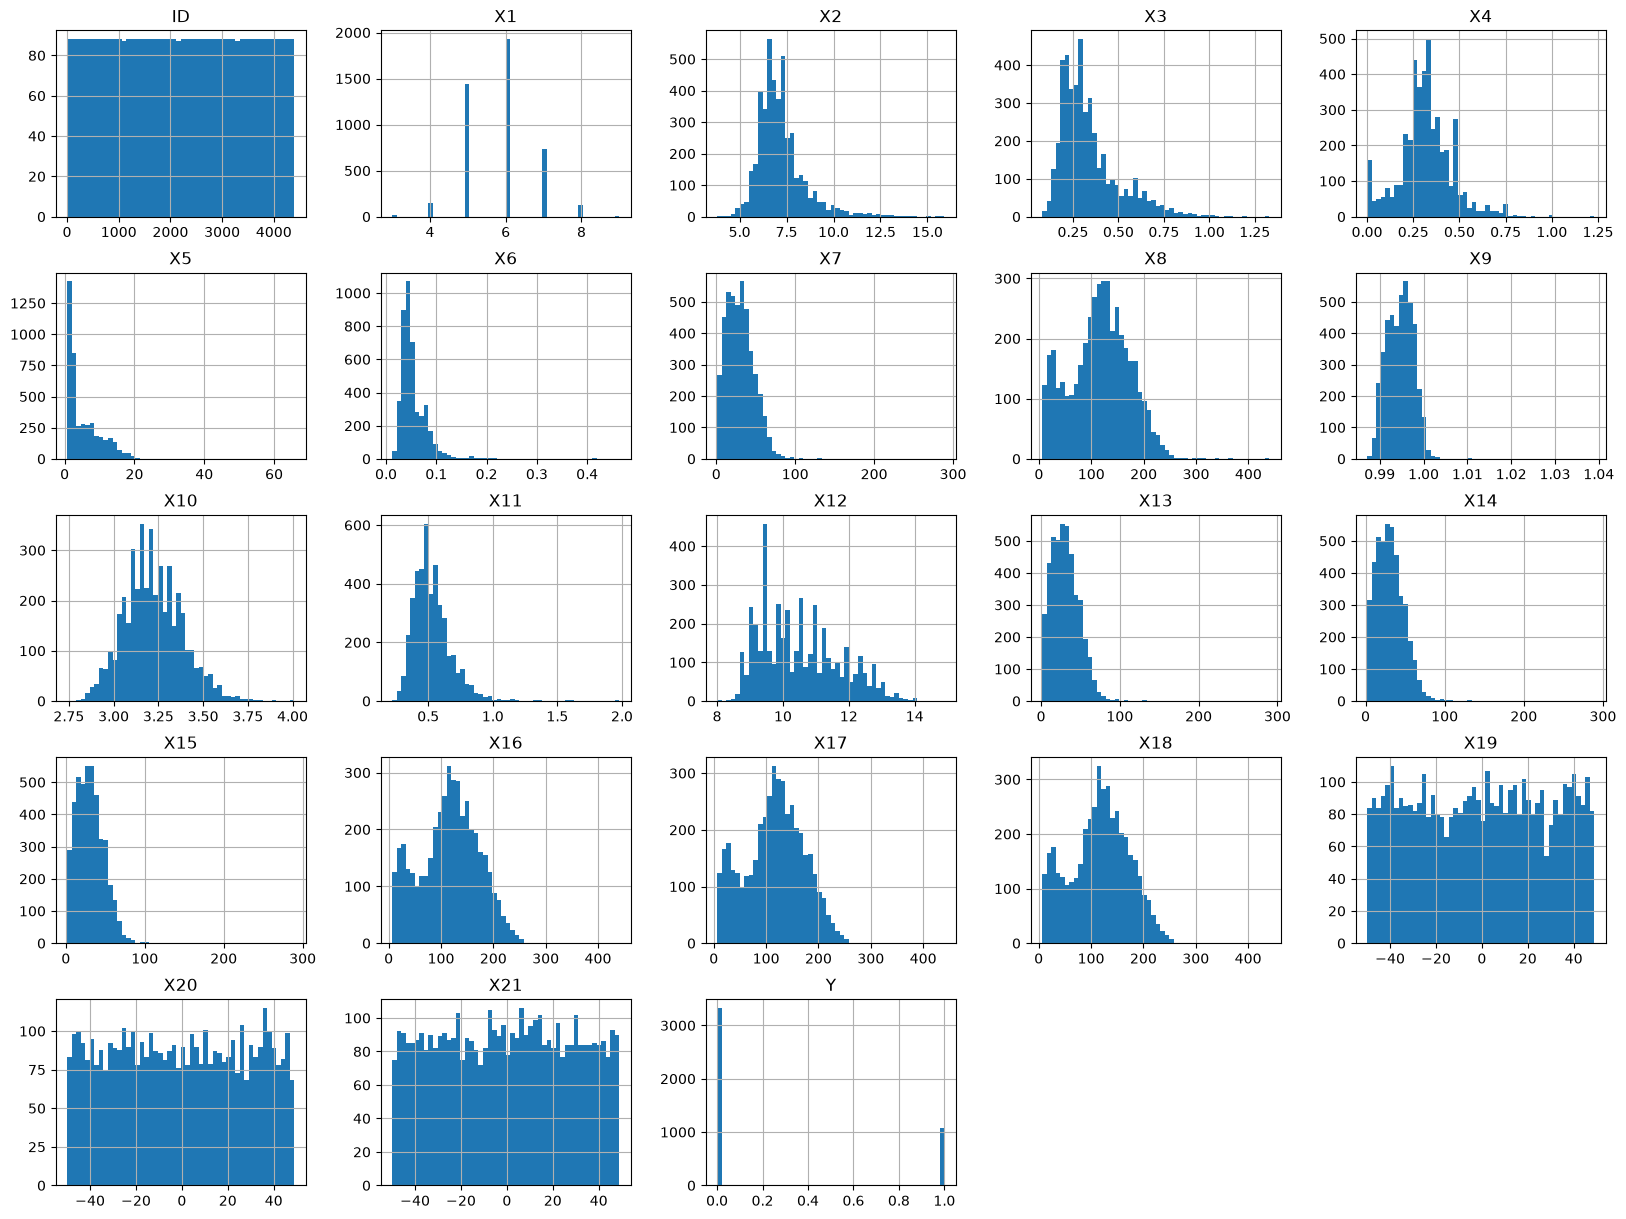

In [13]:
Classification.hist(bins=50,figsize=(20,15)) 
plt.show()

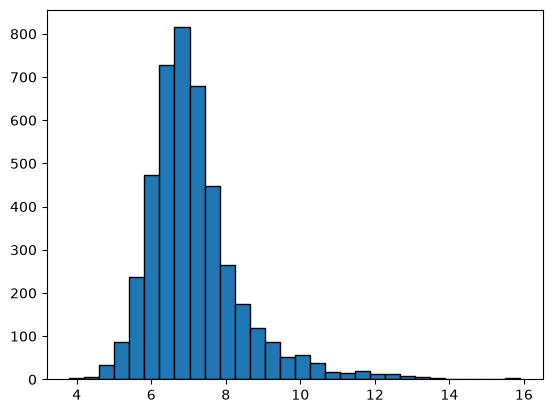

In [14]:
# 특정 변수의 히스토그램을 보고싶을 때
# (matplotlib 라이브러리)
plt.hist(Classification["X2"], bins=30, edgecolor="black")
plt.show()

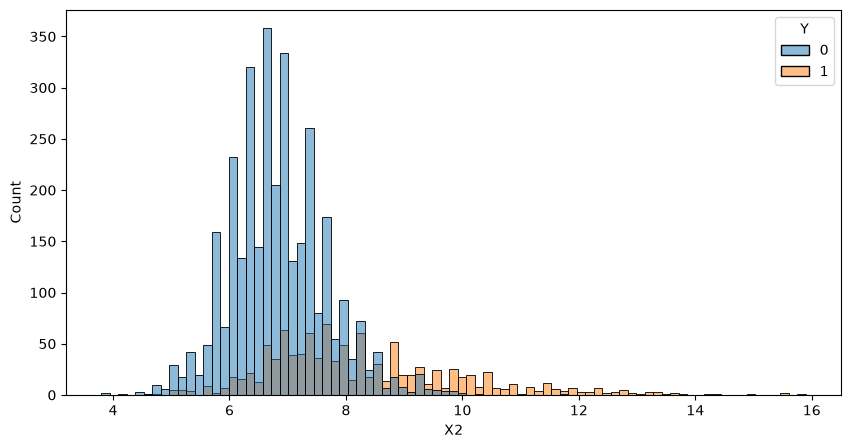

In [15]:
# (Seaborn 라이브러리)
# hue 하나만으로 범주 구분이 용이하다.
plt.figure(figsize=(10,5))   
sns.histplot(data=Classification, x="X2", hue="Y") # hue 옵션을 사용하여 범주를 구분할 수 있음 
plt.show()

> Box Plot

- 박스 플롯은 연속형 변수의 분포를 요약하여 시각화한 그래프임
- 요약 통계량 중 제 1사 분위 (25%), 제 2사 분위 (50%), 제 3사 분위 (75%)를 기반으로 구성됨
- 데이터의 분포 범위, 퍼짐 정도, 이상치 여부를 확인할 수 있음

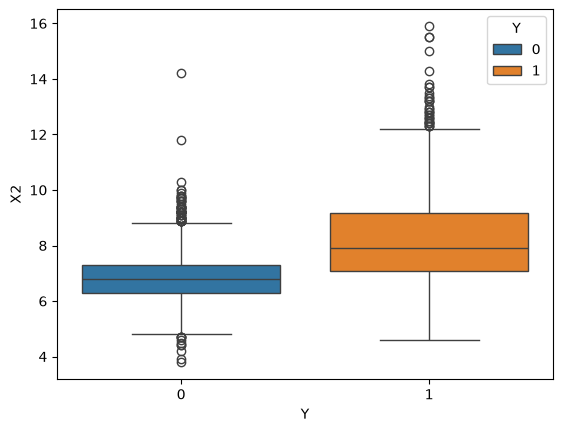

In [16]:
# x축 : 범주형 변수, y축 : 연속형 변수
sns.boxplot(data=Classification, y="X2",x="Y", hue="Y")
plt.show()

> 바이올린 플롯

- 박스 플롯은 분포의 핵심 요약 정보는 보여주지만, 데이터의 구체적인 분포 형태는 알기 어려움
- 바이올린 플롯은 데이터가 어느 구간에 많이 분포하는지 까지 함께 보여줌
- 그룹 간 분포의 모양 차이나 데이터의 집중 구간을 비교하고자 할 때 유용함

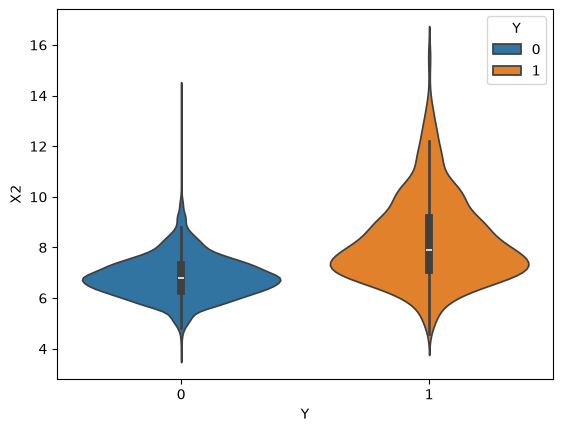

In [17]:
# x축 : 범주형 변수, y축 : 연속형 변수
sns.violinplot(data=Classification, y="X2",x="Y", hue="Y")
plt.show()

#### 1-2-2) 단일 변수 분포 (범주형 변수)

> 막대 그래프

- 막대 그래프는 범주형 데이터를 시각화 하는 데 자주 사용되는 그래프임
- 한 축에는 범주를 나타내고 다른 축에는 각 범주에 해당하는 값 (빈도수, 요약 통계량 등)을 표시함
- 해당 값에 비례하는 길이의 직사각형 막대를 통해 범주 간 크기 차이를 직관적으로 비교할 수 있음

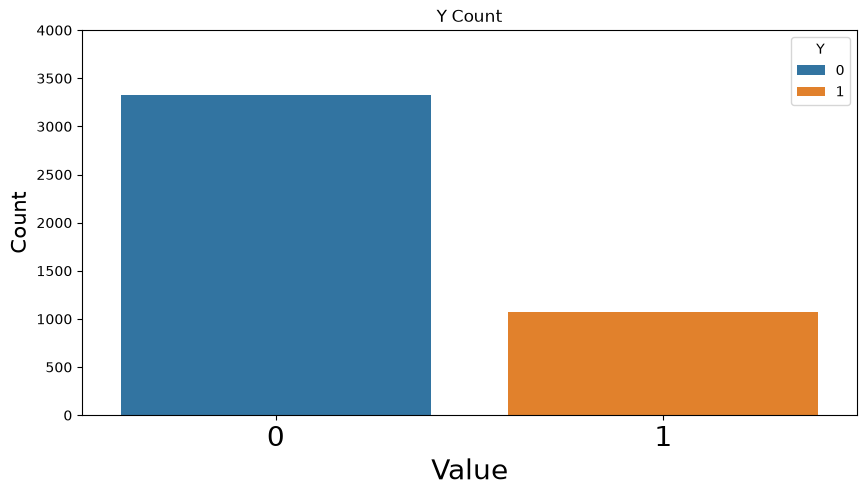

In [18]:
plt.figure(figsize=(10,5))          # 그림 크기 설정
plt.title("Y Count")                # 그림 제목

counts = Classification["Y"].value_counts()   # y의 범주별 빈도수 계산

sns.barplot(x=counts.index,         # x축 : y의 범주
            y=counts.values,        # y축 : 범주별 빈도수
            hue=counts.index)       # 범주별 색상 구분

plt.xticks(fontsize=20)             # x축 눈금 설정
plt.xlabel("Value",fontsize=20)     # x축 레이블 설정
plt.ylabel("Count",fontsize=15)     # y축 레이블 설정
plt.ylim(0,4000)                    # y축 범위 설정 
plt.legend(title="Y")               # 범례 표시
plt.show()

#### 1-2-3) 두 변수 간 관계

> 산점도

- 산점도는 두 연속형 변수 간의 관계 및 상관성을 확인하기 위해 사용하는 그래프임
- 일반적으로 세로축에는 관심있는 변수 (예: Y)를, 가로축에는 해당 변수와 관련 있다고 판단되는 변수를 표시함 
- 상관계수만으로 파악하기 어려운 비선형 관계나 이상치도 함께 확인할 수 있음

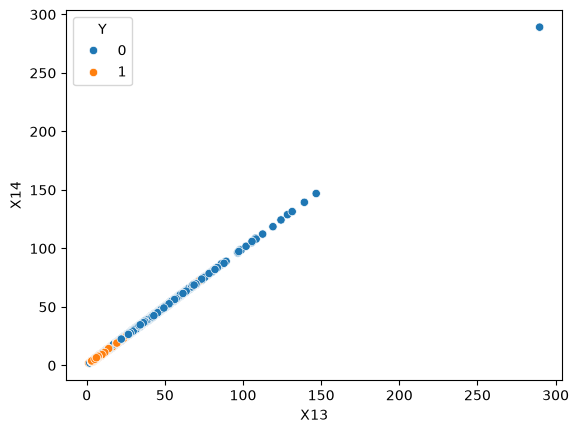

In [19]:
sns.scatterplot(data=Classification, x="X13",y="X14",hue="Y")
plt.show()

#### 1-2-4) 여러 변수 간 관계

> 히트맵

- 히트맵은 데이터 값을 색상으로 표현하여 수치의 크기나 관계를 직관적으로 보여주는 시각화 기법임 
- 데이터 분석에서는 주로 상관계수 행렬이나 범주 간 빈도표 등을 시각화 할 때 활용됨
- 색상의 차이를 통해 값의 높고 낮음이나 변수 간 관계의 강도를 한눈에 파악할 수 있음

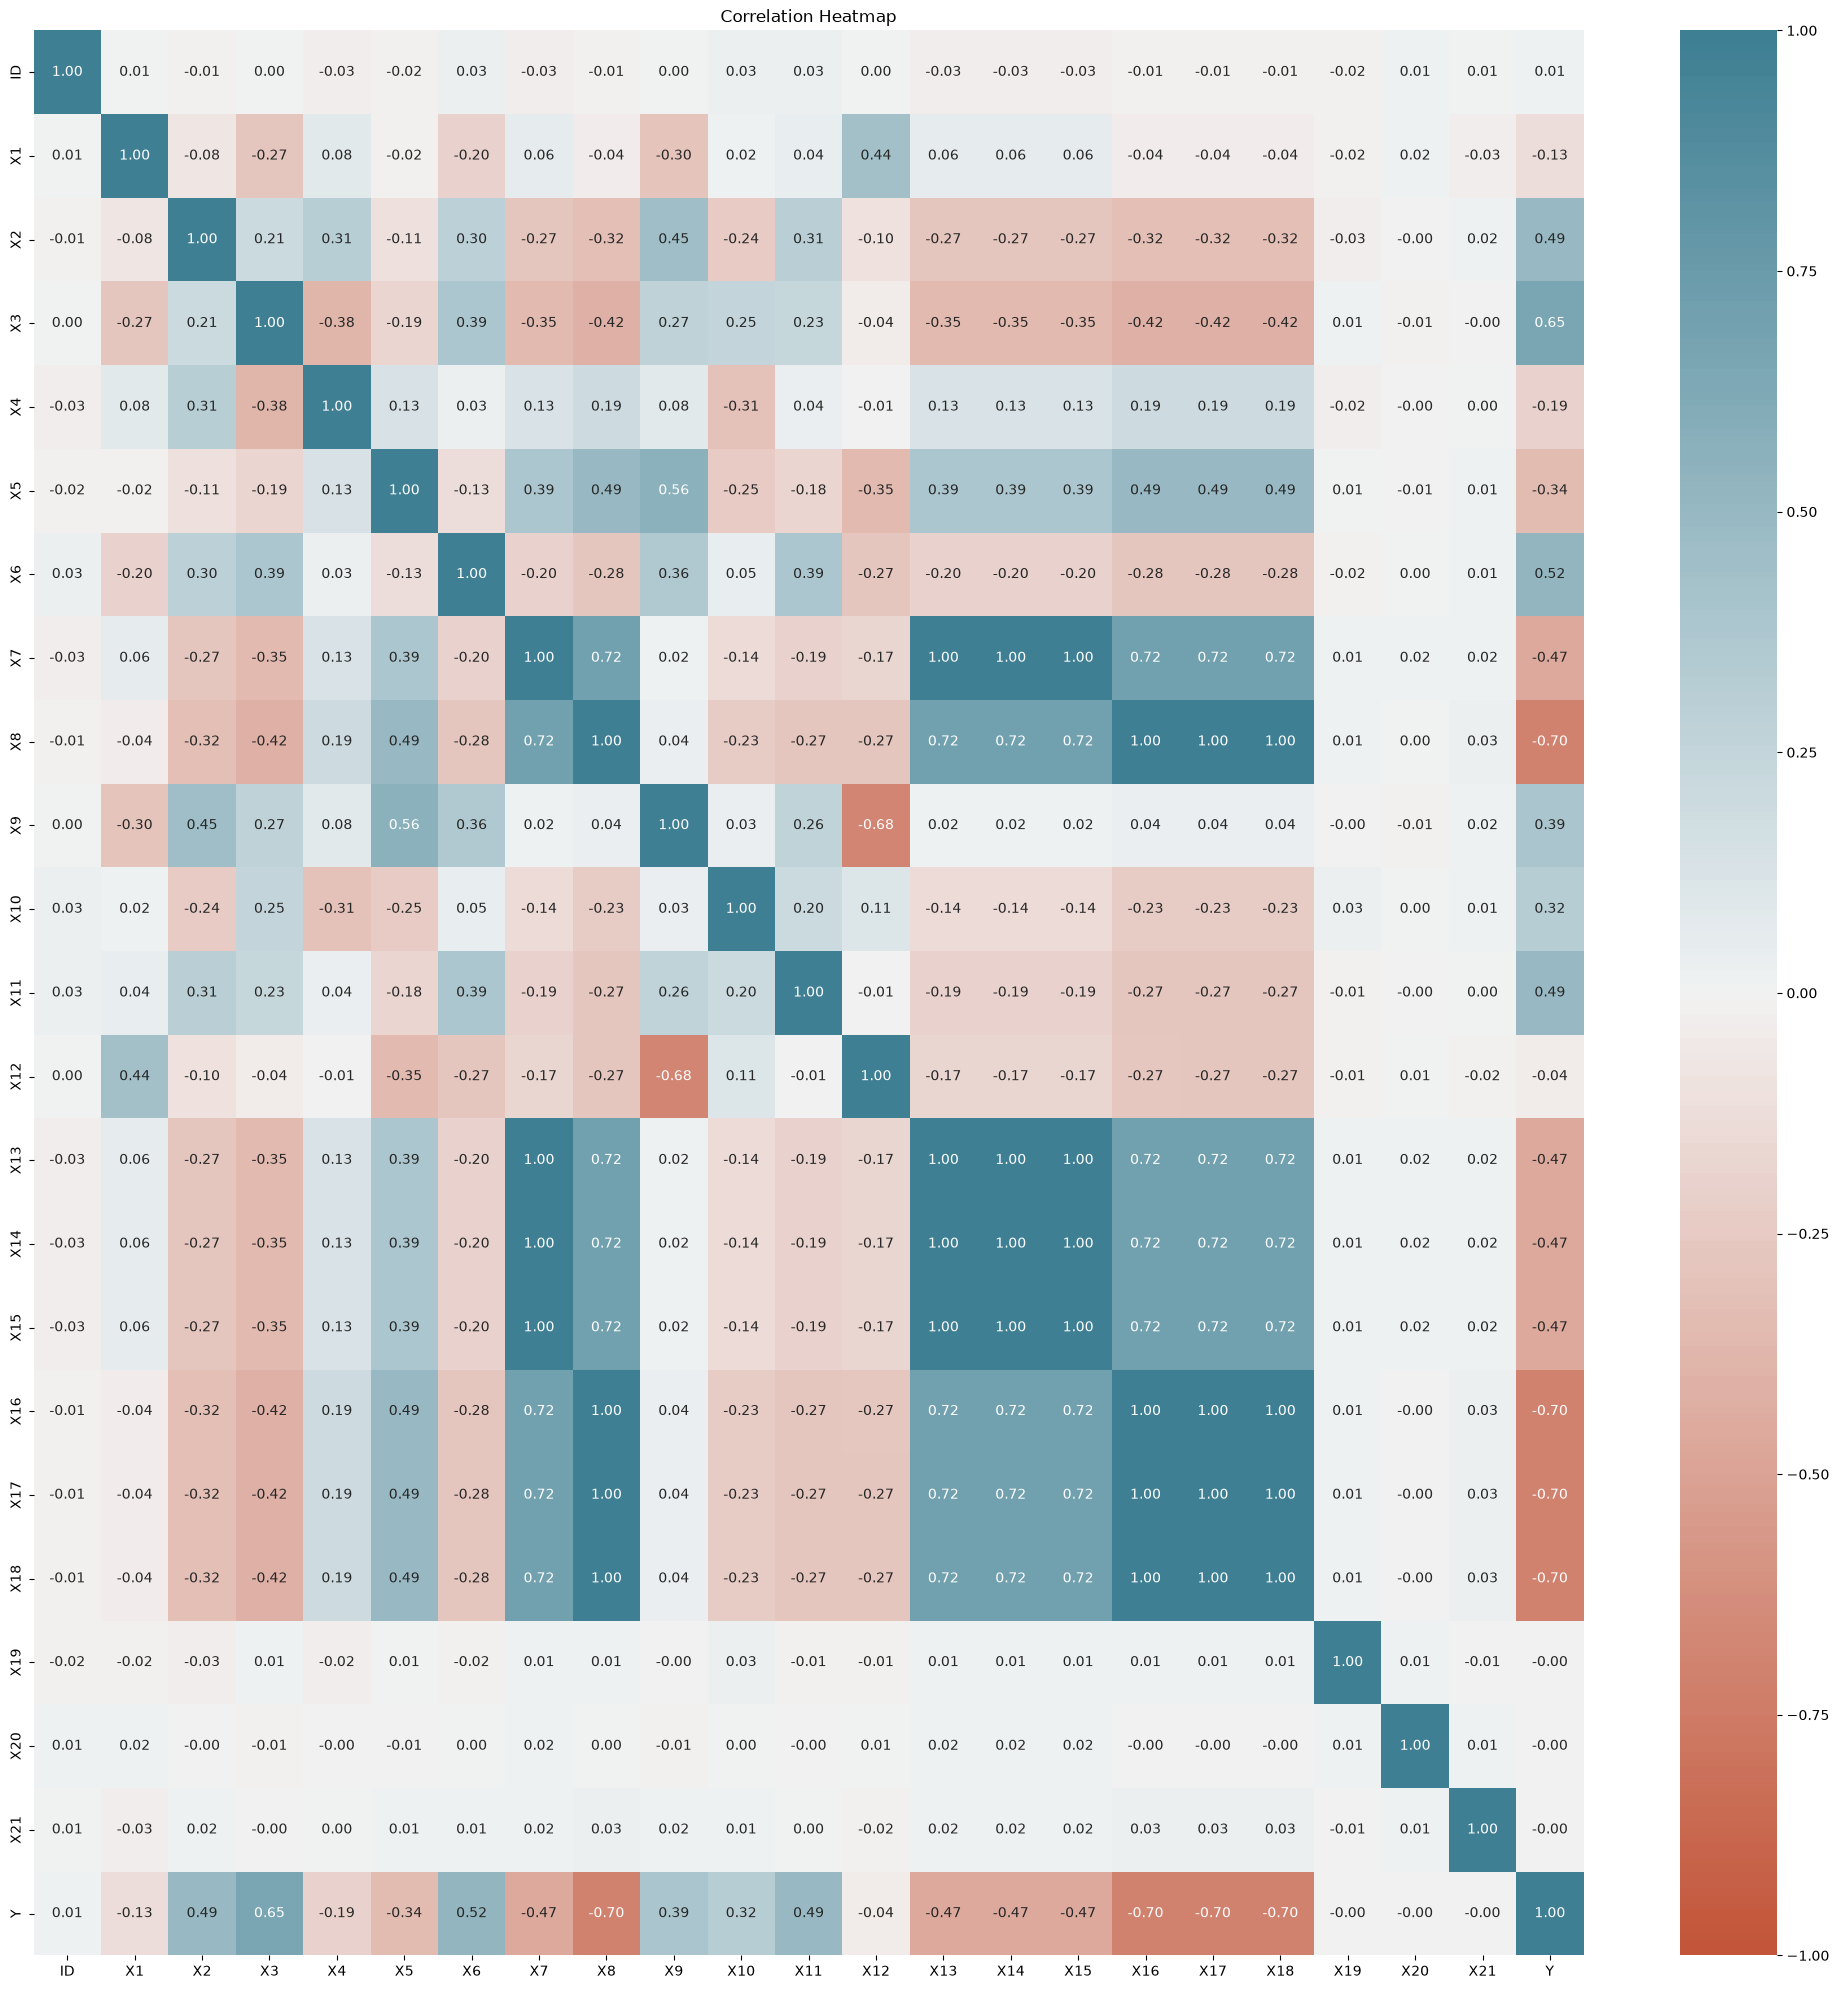

In [20]:
plt.figure(figsize=(25,25))

sns.heatmap(
    Classification.corr(numeric_only=True),
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200), # 색상 팔레트 지정
    annot=True,        # 상관계수 숫자 표시
    fmt=".2f"          # 소수점 2자리
)

plt.title("Correlation Heatmap")
plt.show()

## 2) 데이터 전처리

- 원 데이터를 분석에 적합한 형태로 가공하는 과정을 의미함
    - 예: 특정 변수 제거, 결측치 제거, 이상치 제거, 데이터 정규화 등

### 2-1) 불필요한 입력변수 제거 
> 제거 후보
1. **고유값의 개수가 1개인 변수:** 모든 데이터가 동일한 값을 가지므로 예측에 아무 정보도 제공하지 못함
2. **식별자 변수:** 단순 구분용 정보로, 오히려 모델이 불필요한 패턴을 학습할 수 있음 (예: ID 등)
3. **중복 변수:** 동일하거나 매우 유사한 변수는 다중공선성을 유발하여 모델 안정성을 저하시킬 수 있음

In [21]:
# nunique가 1인 변수 (값이 하나뿐인 상수 컬럼) 확인
print("Regression - 상수 변수:", Regression.columns[Regression.nunique() == 1].tolist())
print("Classification - 상수 변수:", Classification.columns[Classification.nunique() == 1].tolist())

Regression - 상수 변수: []
Classification - 상수 변수: []


In [22]:
# 중복된 변수 (값이 완전히 동일한 컬럼 쌍) 확인
print("Regression - 중복 변수:", Regression.columns[Regression.T.duplicated()].tolist())
print("Classification - 중복 변수:", Classification.columns[Classification.T.duplicated()].tolist())

Regression - 중복 변수: []
Classification - 중복 변수: []


In [23]:
# drop 함수를 사용하여 데이터 프레임의 행 또는 열을 제거할 수 있음 
# 데이터프레임명.drop(변수명 or 행 인덱스 , axis=1 or 0)
# axis=1인 경우에는 열 axis=0인 경우에는 행을 제거함

Classification.drop(["ID"],axis=1,inplace=True)  #지운 뒤 그 테이블로 덮어쓴다;inplace=True

In [24]:
Classification

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X13,X14,X15,X16,X17,X18,X19,X20,X21,Y
0,7,6.5,0.24,0.32,7.6,0.038,48.0,203.0,0.99580,3.45,...,48.799738,48.626499,48.579713,203.348013,203.737225,203.291469,-23,-45,2,0
1,7,5.7,0.26,0.30,1.8,0.039,30.0,105.0,0.98995,3.48,...,30.260525,30.441714,30.466443,105.501698,105.488242,105.993715,27,35,3,0
2,6,6.7,0.31,0.18,7.7,0.043,57.0,200.0,0.99566,3.17,...,57.602229,57.407341,57.246853,200.753456,200.780463,200.797679,13,-35,12,0
3,6,6.7,0.36,0.28,8.3,0.034,29.0,81.0,0.99151,2.96,...,29.240665,29.875582,29.360109,81.168497,81.448285,81.473213,-3,-41,32,0
4,5,7.0,0.78,0.08,2.0,0.093,10.0,19.0,0.99560,3.40,...,10.288176,10.628590,10.663643,19.478898,19.290731,19.775310,-26,-50,-22,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4392,6,6.9,0.28,0.28,12.2,0.042,52.0,139.0,0.99522,3.03,...,52.697197,52.664612,52.380457,139.185435,139.091789,139.023971,2,17,-9,0
4393,7,8.3,0.28,0.48,2.1,0.093,6.0,12.0,0.99408,3.26,...,6.233389,6.584919,6.530149,12.243325,12.019955,12.319226,38,27,-47,1
4394,6,5.7,0.21,0.25,1.1,0.035,26.0,81.0,0.99020,3.31,...,26.468880,26.965323,26.270720,81.042977,81.362418,81.229658,-10,-15,15,0
4395,5,6.7,0.43,0.23,5.0,0.157,49.0,145.0,0.99471,3.17,...,49.384369,49.081814,49.971617,145.873687,145.645990,145.348258,-38,-41,43,0


### 2-2) 결측치 처리 

- 결측치란 관측되어야 할 값이 존재하지 않는 데이터를 뜻함
- 일반적으로 결측치는 빈 공간이거나 예약된 문자열로 표현됨
    -  Python에서는 NaN (Not a Number), None (Null), NA (Not Available) 등으로 표시

In [25]:
# 결측 여부 확인 (True/False)
Regression.isnull()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X50,X51,X52,X53,X54,X55,X56,X57,X58,y
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
237,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
238,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
239,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [26]:
# 변수별 결측값 개수 확인
Regression.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
X24    0
X25    0
X26    0
X27    0
X28    0
X29    0
X30    0
X31    0
X32    0
X33    0
X34    0
X35    0
X36    0
X37    0
X38    0
X39    0
X40    0
X41    0
X42    0
X43    0
X44    0
X45    0
X46    0
X47    0
X48    0
X49    0
X50    0
X51    0
X52    0
X53    0
X54    0
X55    0
X56    0
X57    0
X58    0
y      0
dtype: int64

In [27]:
# 결측 여부 확인 (True/False)
Classification.isnull()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X13,X14,X15,X16,X17,X18,X19,X20,X21,Y
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4392,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4393,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4394,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4395,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [28]:
# 변수별 결측값 개수 확인
Classification.isnull().sum()

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
Y      0
dtype: int64

### 2-3) 데이터 분할

- **Train:** 모델이 학습하는 데 사용하는 데이터. 모델은 이 데이터로 패턴을 배움
- **Validation:** 학습 과정에서 모델 성능을 점검하고 하이퍼파라미터를 조정하는 데 사용하는 데이터. 모델 선택 및 하이퍼파라미터 최적화의 기준이 되며, 최종 평가에는 쓰지 않음
- **Test:** 학습이 모두 끝난 후, 모델의 최종 성능을 평가하는 데 사용하는 데이터. 학습 및 최적화 과정에서 한 번도 보지 않은 데이터로 일반화 성능을 측정함

In [30]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.2 MB 15.1 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.2 MB 18.2 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 18.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 18.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 18.6 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 18.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 5.7 MB/s  0:00:01
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/36.6 MB 22.4 MB/s eta 0:00:02
   --------- ------------------------------ 8.7/36.6 MB 21.5 MB/s eta 0:00:02
   --------------- ------------------------ 14.2/36.6 MB 22.8 MB/s eta 0:00:01
   --------------------- ------------------ 19.4/36.6 MB 23.1 MB/s eta 0:00:01
   ---------

In [31]:
from sklearn.model_selection import train_test_split

# 입력변수와 출력변수로 분할
X_reg = Regression.drop(["y"], axis=1)
Y_reg = Regression["y"]

X_cla = Classification.drop(["Y"], axis=1)
Y_cla = Classification["Y"]

In [32]:
# [회귀] 학습 데이터와 테스트 데이터로 분할

# test_size는 전체 데이터 크기 중 test 데이터의 크기를 얼마의 비중으로 할 것이냐를 뜻함
# random_state는 난수를 고정해주는 함수로, 동일한 값에서는 동일한 데이터가 뽑힘

X_reg_train, X_reg_test, Y_reg_train, Y_reg_test = train_test_split(
    X_reg, Y_reg, test_size=0.3, random_state=42)

print(Regression.shape, X_reg_train.shape, X_reg_test.shape, Y_reg_train.shape, Y_reg_test.shape)
X_reg_train.head(n=5)

(241, 59) (168, 58) (73, 58) (168,) (73,)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X49,X50,X51,X52,X53,X54,X55,X56,X57,X58
29,0.38245,0.38585,0.38435,0.43340,0.32350,0.38865,0.43280,0.39545,0.41605,0.40050,...,0.36285,0.38380,0.39980,0.38830,0.43655,0.40410,0.42995,0.31040,0.39180,0.38310
120,0.36015,0.40050,0.35295,0.42870,0.32960,0.34465,0.40170,0.35255,0.36310,0.42060,...,0.35705,0.37395,0.40440,0.45750,0.39430,0.37135,0.41180,0.30560,0.34590,0.36105
114,0.37905,0.37205,0.50075,0.37745,0.19050,0.32285,0.47210,0.49905,0.55430,0.49745,...,0.30360,0.32680,0.39495,0.34510,0.29395,0.48245,0.32230,0.26090,0.42185,0.41925
177,0.36290,0.37540,0.34030,0.45120,0.32030,0.34860,0.41210,0.34315,0.34675,0.40530,...,0.35120,0.39000,0.40760,0.44295,0.44405,0.37155,0.44955,0.29015,0.32990,0.35870
5,0.44835,0.36090,0.28100,0.31305,0.55775,0.38180,0.39345,0.32535,0.35885,0.45745,...,0.41350,0.31985,0.34195,0.35290,0.36950,0.45550,0.28210,0.53420,0.41720,0.31115


In [33]:
# [분류] 학습 데이터와 테스트 데이터로 분할
# stratify=Y 옵션은 클래스 비율에 맞게 학습 데이터와 테스트 데이터를 분할해 주는 옵션

X_cla_train, X_cla_test, Y_cla_train, Y_cla_test = train_test_split(
    X_cla, Y_cla, test_size=0.3, random_state=42, stratify=Y_cla)

print(Classification.shape, X_cla_train.shape, X_cla_test.shape, Y_cla_train.shape, Y_cla_test.shape)
X_cla_train.head(n=5)

(4397, 22) (3077, 21) (1320, 21) (3077,) (1320,)


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21
2585,6,5.9,0.36,0.41,1.3,0.047,45.0,104.0,0.99170,3.33,...,10.6,45.678962,45.390442,45.574113,104.913573,104.516439,104.886182,-8,41,36
1895,5,6.1,0.64,0.02,2.4,0.069,26.0,46.0,0.99358,3.47,...,11.0,26.369223,26.450417,26.626659,46.078321,46.461274,46.765529,-11,-27,-26
616,7,7.2,0.26,0.24,7.0,0.023,19.0,130.0,0.99176,3.14,...,12.8,19.670686,19.103430,19.619806,130.954302,130.159757,130.334219,-7,-23,12
2721,7,8.4,0.22,0.30,1.3,0.038,45.0,122.0,0.99178,3.13,...,10.8,45.551191,45.684731,45.485596,122.283112,122.465188,122.561181,-23,-39,-5
2787,7,8.2,0.29,0.33,9.1,0.036,28.0,118.0,0.99530,2.96,...,10.9,28.814631,28.036001,28.240522,118.678836,118.925528,118.111504,37,14,44


In [34]:
# [분류] stratify 옵션으로 클래스 비율이 유지되는지 확인

print("원 데이터 Y 분포")
print(Y_cla.value_counts(normalize=True))
print(" ")
print("학습 데이터 Y 분포")
print(Y_cla_train.value_counts(normalize=True))
print(" ")
print("테스트 데이터 Y 분포")
print(Y_cla_test.value_counts(normalize=True))

원 데이터 Y 분포
Y
0    0.756652
1    0.243348
Name: proportion, dtype: float64
 
학습 데이터 Y 분포
Y
0    0.756581
1    0.243419
Name: proportion, dtype: float64
 
테스트 데이터 Y 분포
Y
0    0.756818
1    0.243182
Name: proportion, dtype: float64


### 2-4) 변수 스케일링

#### 2-4-1) 수치형 변수 스케일링

- 변수 간 단위(스케일) 차이가 크면 값이 큰 변수가 결과를 지배하고 작은 변수는 무시되므로, 모든 변수를 동일한 척도로 맞추는 스케일링이 필요함

1. **Min-Max Scaling:** 모든 값을 0~1 범위로 변환 (이상치가 적은 데이터에 적합)
2. **Z-score Scaling:** 평균 0, 표준편차 1이 되도록 변환 (정규분포에 가까운 데이터에 적합)

In [ ]:
from sklearn.preprocessing import MinMaxScaler # Min-Max scaling 함수 호출

# 스케일링 기준(fit)은 반드시 train에서만 생성 → test에는 train 기준을 적용(transform)만
# test까지 사용해 기준을 만들면 모델이 미리 정보를 참고하는 데이터 누수(Data Leakage)가 발생함

# [회귀] 복사본 생성
X_reg_train_minmax = X_reg_train.copy()
X_reg_test_minmax = X_reg_test.copy()

# 수치형 변수만 선택
num_cols_reg = X_reg_train_minmax.select_dtypes(include=['int64','float64']).columns

# scaler 생성
scaler_mm_reg = MinMaxScaler()

# train에 fit, test에는 transform만
X_reg_train_minmax[num_cols_reg] = scaler_mm_reg.fit_transform(X_reg_train_minmax[num_cols_reg])
X_reg_test_minmax[num_cols_reg] = scaler_mm_reg.transform(X_reg_test_minmax[num_cols_reg])  # test group에는 transform만 해준다. 기준치는 train group에서 뽑음

In [38]:
X_reg_train_minmax.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X49,X50,X51,X52,X53,X54,X55,X56,X57,X58
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,...,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,0.569481,0.533125,0.486830,0.496664,0.564453,0.441601,0.534658,0.501848,0.484824,0.597462,...,0.507338,0.438349,0.534937,0.472382,0.525551,0.614931,0.411958,0.455448,0.514300,0.476635
std,0.203524,0.213201,0.218153,0.162029,0.203843,0.206093,0.193646,0.207490,0.190130,0.173644,...,0.208679,0.185745,0.190646,0.187313,0.158640,0.170510,0.172136,0.212773,0.182439,0.206391
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.437408,0.385767,0.317749,0.397842,0.404249,0.292989,0.406108,0.349641,0.366231,0.490259,...,0.365126,0.312370,0.406445,0.343978,0.430159,0.499683,0.295816,0.285697,0.380579,0.330902
50%,0.582736,0.524169,0.467901,0.503988,0.577856,0.427249,0.543305,0.495532,0.498737,0.616198,...,0.483730,0.429259,0.525493,0.476303,0.519409,0.598386,0.414642,0.435642,0.528930,0.477177
75%,0.702259,0.686842,0.653678,0.601465,0.704052,0.592725,0.657797,0.658745,0.594828,0.708847,...,0.650377,0.538516,0.659131,0.592923,0.612478,0.742824,0.502342,0.606341,0.622225,0.622733
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [39]:
# [분류] 복사본 생성
X_cla_train_minmax = X_cla_train.copy()
X_cla_test_minmax = X_cla_test.copy()

# 수치형 변수만 선택
num_cols_cla = X_cla_train_minmax.select_dtypes(include=['int64','float64']).columns

# scaler 생성
scaler_mm_cla = MinMaxScaler()

# train에 fit, test에는 transform만
X_cla_train_minmax[num_cols_cla] = scaler_mm_cla.fit_transform(X_cla_train_minmax[num_cols_cla])
X_cla_test_minmax[num_cols_cla] = scaler_mm_cla.transform(X_cla_test_minmax[num_cols_cla])

In [40]:
X_cla_train

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21
2585,6,5.9,0.36,0.41,1.3,0.047,45.0,104.0,0.99170,3.33,...,10.6,45.678962,45.390442,45.574113,104.913573,104.516439,104.886182,-8,41,36
1895,5,6.1,0.64,0.02,2.4,0.069,26.0,46.0,0.99358,3.47,...,11.0,26.369223,26.450417,26.626659,46.078321,46.461274,46.765529,-11,-27,-26
616,7,7.2,0.26,0.24,7.0,0.023,19.0,130.0,0.99176,3.14,...,12.8,19.670686,19.103430,19.619806,130.954302,130.159757,130.334219,-7,-23,12
2721,7,8.4,0.22,0.30,1.3,0.038,45.0,122.0,0.99178,3.13,...,10.8,45.551191,45.684731,45.485596,122.283112,122.465188,122.561181,-23,-39,-5
2787,7,8.2,0.29,0.33,9.1,0.036,28.0,118.0,0.99530,2.96,...,10.9,28.814631,28.036001,28.240522,118.678836,118.925528,118.111504,37,14,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4369,6,5.2,0.16,0.34,0.8,0.029,26.0,77.0,0.99155,3.25,...,10.1,26.238347,26.133254,26.625281,77.457839,77.956114,77.197699,22,-15,-7
2145,5,7.0,0.48,0.12,4.5,0.050,23.0,86.0,0.99398,2.86,...,9.0,23.797194,23.381834,23.421734,86.581672,86.757620,86.768451,-18,-35,-20
2978,7,7.2,0.48,0.07,5.5,0.089,10.0,18.0,0.99684,3.37,...,11.2,10.386342,10.811689,10.673641,18.673522,18.965811,18.510614,38,13,28
2163,6,6.4,0.30,0.45,3.5,0.197,76.0,180.0,0.99420,3.02,...,9.1,76.081986,76.329838,76.361315,180.402743,180.157348,180.975950,5,-15,-21


In [42]:
X_cla_train_minmax.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21
count,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,...,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000,3077.000000
mean,0.469884,0.288404,0.206509,0.258839,0.072941,0.097091,0.102124,0.252067,0.145076,0.353807,...,0.416674,0.102671,0.100851,0.101848,0.251893,0.251255,0.252093,0.506462,0.497359,0.502700
std,0.144166,0.107063,0.130267,0.116665,0.073921,0.075714,0.061872,0.129032,0.058716,0.133417,...,0.197619,0.061805,0.062047,0.061875,0.128946,0.129173,0.129021,0.292871,0.290177,0.288991
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.333333,0.222222,0.120000,0.203252,0.016897,0.057522,0.055556,0.165899,0.099287,0.262295,...,0.247934,0.055811,0.053829,0.054722,0.165796,0.165608,0.166106,0.252525,0.252525,0.252525
50%,0.500000,0.273504,0.168000,0.252033,0.035330,0.077434,0.097222,0.258065,0.148255,0.344262,...,0.396694,0.096957,0.094890,0.095877,0.258166,0.257428,0.258486,0.525253,0.494949,0.505051
75%,0.500000,0.324786,0.256000,0.317073,0.113671,0.117257,0.138889,0.341014,0.188741,0.434426,...,0.561983,0.139878,0.138378,0.138917,0.340263,0.339897,0.340834,0.757576,0.747475,0.747475
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [43]:
from sklearn.preprocessing import StandardScaler # Standard scaling 함수 호출

# [회귀] 복사본 생성
X_reg_train_standard = X_reg_train.copy()
X_reg_test_standard = X_reg_test.copy()

# 수치형 변수만 선택
num_cols_reg = X_reg_train_standard.select_dtypes(include=['int64','float64']).columns

# scaler 생성
scaler_std_reg = StandardScaler()

# train에 fit, test에는 transform만
X_reg_train_standard[num_cols_reg] = scaler_std_reg.fit_transform(X_reg_train_standard[num_cols_reg])
X_reg_test_standard[num_cols_reg] = scaler_std_reg.transform(X_reg_test_standard[num_cols_reg])

In [44]:
# [분류] 복사본 생성
X_cla_train_standard = X_cla_train.copy()
X_cla_test_standard = X_cla_test.copy()

# 수치형 변수만 선택
num_cols_cla = X_cla_train_standard.select_dtypes(include=['int64','float64']).columns

# scaler 생성
scaler_std_cla = StandardScaler()

# train에 fit, test에는 transform만
X_cla_train_standard[num_cols_cla] = scaler_std_cla.fit_transform(X_cla_train_standard[num_cols_cla])
X_cla_test_standard[num_cols_cla] = scaler_std_cla.transform(X_cla_test_standard[num_cols_cla])

In [45]:
X_cla_train

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21
2585,6,5.9,0.36,0.41,1.3,0.047,45.0,104.0,0.99170,3.33,...,10.6,45.678962,45.390442,45.574113,104.913573,104.516439,104.886182,-8,41,36
1895,5,6.1,0.64,0.02,2.4,0.069,26.0,46.0,0.99358,3.47,...,11.0,26.369223,26.450417,26.626659,46.078321,46.461274,46.765529,-11,-27,-26
616,7,7.2,0.26,0.24,7.0,0.023,19.0,130.0,0.99176,3.14,...,12.8,19.670686,19.103430,19.619806,130.954302,130.159757,130.334219,-7,-23,12
2721,7,8.4,0.22,0.30,1.3,0.038,45.0,122.0,0.99178,3.13,...,10.8,45.551191,45.684731,45.485596,122.283112,122.465188,122.561181,-23,-39,-5
2787,7,8.2,0.29,0.33,9.1,0.036,28.0,118.0,0.99530,2.96,...,10.9,28.814631,28.036001,28.240522,118.678836,118.925528,118.111504,37,14,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4369,6,5.2,0.16,0.34,0.8,0.029,26.0,77.0,0.99155,3.25,...,10.1,26.238347,26.133254,26.625281,77.457839,77.956114,77.197699,22,-15,-7
2145,5,7.0,0.48,0.12,4.5,0.050,23.0,86.0,0.99398,2.86,...,9.0,23.797194,23.381834,23.421734,86.581672,86.757620,86.768451,-18,-35,-20
2978,7,7.2,0.48,0.07,5.5,0.089,10.0,18.0,0.99684,3.37,...,11.2,10.386342,10.811689,10.673641,18.673522,18.965811,18.510614,38,13,28
2163,6,6.4,0.30,0.45,3.5,0.197,76.0,180.0,0.99420,3.02,...,9.1,76.081986,76.329838,76.361315,180.402743,180.157348,180.975950,5,-15,-21


In [47]:
X_cla_train_standard.describe()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21
count,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,...,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03,3.077000e+03
mean,-1.656855e-16,-4.318216e-16,-1.431708e-16,7.273999e-17,2.964443e-16,7.851301e-17,9.236825e-17,-2.424666e-17,7.466818e-15,1.334433e-15,...,4.589547e-16,1.524076e-16,1.593352e-16,9.467745e-17,3.665865e-16,5.888476e-17,1.905095e-16,2.424666e-17,-2.857643e-17,-1.847365e-17
std,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,...,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00,1.000163e+00
min,-3.259846e+00,-2.694204e+00,-1.585534e+00,-2.219011e+00,-9.869016e-01,-1.282539e+00,-1.650842e+00,-1.953841e+00,-2.471194e+00,-2.652313e+00,...,-2.108816e+00,-1.661496e+00,-1.625649e+00,-1.646300e+00,-1.953801e+00,-1.945425e+00,-1.954202e+00,-1.729583e+00,-1.714262e+00,-1.739786e+00
25%,-9.473282e-01,-6.182542e-01,-6.641983e-01,-4.765428e-01,-7.582824e-01,-5.226882e-01,-7.527792e-01,-6.679139e-01,-7.799615e-01,-6.860184e-01,...,-8.540063e-01,-7.583254e-01,-7.579547e-01,-7.617564e-01,-6.678103e-01,-6.631505e-01,-6.665593e-01,-8.672017e-01,-8.438758e-01,-8.658259e-01
50%,2.089308e-01,-1.391889e-01,-2.956639e-01,-5.835032e-02,-5.088797e-01,-2.596630e-01,-7.923175e-02,4.649025e-02,5.416112e-02,-7.155136e-02,...,-1.011206e-01,-9.248056e-02,-9.608854e-02,-9.651214e-02,4.865753e-02,4.779392e-02,4.956166e-02,6.416990e-02,-8.305018e-03,8.134621e-03
75%,2.089308e-01,3.398764e-01,3.799825e-01,4.992396e-01,5.510818e-01,2.663875e-01,5.943157e-01,6.894540e-01,7.437901e-01,6.043624e-01,...,7.354190e-01,6.021095e-01,6.049194e-01,5.991960e-01,6.854329e-01,6.863393e-01,6.879158e-01,8.575605e-01,8.620812e-01,8.471367e-01
max,3.677708e+00,6.647569e+00,6.092266e+00,6.353934e+00,1.254320e+01,1.192717e+01,1.451430e+01,5.797444e+00,1.456264e+01,4.844185e+00,...,2.952249e+00,1.452117e+01,1.449370e+01,1.451798e+01,5.802662e+00,5.797397e+00,5.797718e+00,1.685446e+00,1.732467e+00,1.721097e+00


In [48]:
print(X_cla_train["X1"].value_counts().sort_index())

X1
3      10
4     112
5     990
6    1367
7     511
8      84
9       3
Name: count, dtype: int64


In [49]:
print(X_cla_train_standard["X1"].value_counts().sort_index())

X1
-3.259846      10
-2.103587     112
-0.947328     990
 0.208931    1367
 1.365190     511
 2.521449      84
 3.677708       3
Name: count, dtype: int64


#### 2-4-2) 범주형 변수 전처리

- 머신러닝 모델은 숫자만 처리할 수 있으므로, 문자열 범주는 숫자로 변환하는 인코딩이 필요함

1. **Label Encoding:** 각 범주에 고유한 정수를 부여 (범주 간 순서가 있을 때 적합, 예: 웨이퍼 품질 등급)
2. **One-hot Encoding:** 각 범주를 독립된 열로 분리해 0과 1로 표현 (범주 간 순서가 없을 때 적합, 예: 공정 장비(챔버) 종류)

In [50]:
# 현재 실습 데이터는 모두 수치형이라, 범주형 인코딩은 개념 이해를 위해 예시 데이터로만 시연

# 예시용 범주형 데이터 (공정 장비 종류)
toy = pd.DataFrame({"장비": ["A_chamber", "B_chamber", "C_chamber", "A_chamber", "B_chamber"]})
toy

,장비
0,A_chamber
1,B_chamber
2,C_chamber
3,A_chamber
4,B_chamber


In [51]:
from sklearn.preprocessing import LabelEncoder

# Label Encoding: 각 범주를 고유 정수로 변환
le = LabelEncoder()
toy_label = toy.copy()
toy_label["장비_label"] = le.fit_transform(toy_label["장비"])
toy_label

,장비,장비_label
0,A_chamber,0
1,B_chamber,1
2,C_chamber,2
3,A_chamber,0
4,B_chamber,1


In [52]:
# One-hot Encoding: 각 범주를 독립된 0/1 열로 분리
toy_onehot = pd.get_dummies(toy, columns=["장비"])
toy_onehot

,장비_A_chamber,장비_B_chamber,장비_C_chamber
0,True,False,False
1,False,True,False
2,False,False,True
3,True,False,False
4,False,True,False


---

## 3) 모델링

In [53]:
# 모델에 입력될 최종 데이터 생성

# [회귀] 최종 학습/평가 데이터
X_reg_train_final = X_reg_train_standard.copy()
X_reg_test_final = X_reg_test_standard.copy()

Y_reg_train_final = Y_reg_train.copy()
Y_reg_test_final = Y_reg_test.copy()

# [분류] 최종 학습/평가 데이터
X_cla_train_final = X_cla_train_standard.copy()
X_cla_test_final = X_cla_test_standard.copy()

Y_cla_train_final = Y_cla_train.copy()
Y_cla_test_final = Y_cla_test.copy()

- Scikit-Learn은 대부분의 머신러닝 모델을 제공하고 있는 머신러닝 라이브러리임

1. 모델 생성 및 학습
2. 테스트 데이터에 대한 예측 진행
3. 성능 평가 (이를 통해 모델 옵션 및 하이퍼파라미터 변경)
4. 모델 속성 확인 및 인사이트 도출

### 3-1) 모델 생성 및 학습

In [54]:
%pip install xgboost lightgbm catboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 2.6/69.5 MB 13.7 MB/s eta 0:00:05
   --- ------------------------------------ 5.2/69.5 MB 13.3 MB/s eta 0:00:05
   ---- ----------------------------------- 7.3/69.5 MB 14.6 MB/s eta 0:00:05
   ---- ----------------------------------- 8.7/69.5 MB 10.3 MB/s eta 0:00:06
   ------ --------------------------------- 11.5/69.5 MB 12.0 MB/s eta 0:00:05
   -------- ------------------------------- 14.9/69.5 MB 11.9 MB/s eta 0:00:05
   --------- ------------------------------ 16.8/69.5 MB 12.4 MB/s eta 0:00:05
   --------- ------------------------------ 17.0/69.5 MB 10.0 MB/s eta 0:00:06
   ------------ --------------------------- 21.2/69.5 MB 11.2 MB/s eta 0:00:05
   -------------- ------------------------- 24.6/69.5 MB 11.6 MB/s eta 0:00:04
   ---------------- ----------------------- 29.1/69.5 MB 12.6 MB/s eta 0:00:04
   ------------------- -------------------- 33.6/69.5 MB 13.2 MB/

In [55]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# 회귀 모델들
reg_models = {
    "LinearRegression": LinearRegression(),                    # 선형회귀
    "Ridge": Ridge(),                                          # Ridge 
    "Lasso": Lasso(),                                          # Lasso 
    "DecisionTree": DecisionTreeRegressor(random_state=0),     # 의사결정나무
    "RandomForest": RandomForestRegressor(random_state=0),     # 랜덤포레스트
    "GBM": GradientBoostingRegressor(random_state=0),          # GBM
    "XGBoost": XGBRegressor(random_state=0),                   # XGBoost
    "LightGBM": LGBMRegressor(random_state=0, verbose=-1),     # LightGBM
    "CatBoost": CatBoostRegressor(random_state=0, verbose=0),  # CatBoost
}

# verbose: 학습 과정에 대한 내용을 얼마나 출력할지를 결정 (클수록 많이 보겠다는의미임)

In [56]:
# fit 함수에 학습 데이터를 넣으면 모델이 해당 데이터의 패턴을 학습함

for name, model in reg_models.items():
    model.fit(X_reg_train_final, Y_reg_train_final)   # 학습 데이터로 모델 학습
    print(f"{name} 학습 완료")

LinearRegression 학습 완료
Ridge 학습 완료
Lasso 학습 완료
DecisionTree 학습 완료
RandomForest 학습 완료
GBM 학습 완료
XGBoost 학습 완료
LightGBM 학습 완료
CatBoost 학습 완료


In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# 분류 모델들
cla_models = {
    "Logistic": LogisticRegression(max_iter=1000),             # 로지스틱 회귀
    "DecisionTree": DecisionTreeClassifier(random_state=0),    # 의사결정나무
    "RandomForest": RandomForestClassifier(random_state=0),    # 랜덤포레스트
    "GBM": GradientBoostingClassifier(random_state=0),         # GBM
    "XGBoost": XGBClassifier(random_state=0),                  # XGBoost
    "LightGBM": LGBMClassifier(random_state=0, verbose=-1),    # LightGBM
    "CatBoost": CatBoostClassifier(random_state=0, verbose=0), # CatBoost
}

In [58]:
# fit 함수에 학습 데이터를 넣으면 모델이 해당 데이터의 패턴을 학습함

for name, model in cla_models.items():
    model.fit(X_cla_train_final, Y_cla_train_final)   # 학습 데이터로 모델 학습
    print(f"{name} 학습 완료")

Logistic 학습 완료
DecisionTree 학습 완료
RandomForest 학습 완료
GBM 학습 완료
XGBoost 학습 완료
LightGBM 학습 완료
CatBoost 학습 완료


### 3-2) 테스트 데이터에 대한 예측 진행

In [59]:
# predict 함수에 테스트 입력변수를 넣으면, 학습된 모델이 출력변수를 예측함

reg_preds = {}
for name, model in reg_models.items():
    reg_preds[name] = model.predict(X_reg_test_final)   # 테스트 입력변수로 예측

In [60]:
# predict      : 클래스(0/1) 예측
# predict_proba: 양성(1) 클래스일 확률 → AUC 등 확률 기반 지표에 사용

cla_preds = {}   # 클래스 예측값
cla_probs = {}   # 양성 확률값
for name, model in cla_models.items():
    cla_preds[name] = model.predict(X_cla_test_final)               # 클래스 예측
    cla_probs[name] = model.predict_proba(X_cla_test_final)[:, 1]   # 양성 확률 ([:,1]은 1번 클래스 확률)

### 3-3) 성능 평가

In [61]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             accuracy_score, recall_score, precision_score,
                             f1_score, roc_auc_score, confusion_matrix)

# [회귀 성능지표] MAE, MSE, MAPE를 계산해 딕셔너리로 반환
def get_reg_score(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)                   # 평균 절대 오차
    mse = mean_squared_error(y_true, y_pred)                    # 평균 제곱 오차
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100    # 평균 절대 백분율 오차(%)
    return {"MAE": mae, "MSE": mse, "MAPE(%)": mape}

# [분류 성능지표] 혼동행렬에서 지표를 뽑아 딕셔너리로 반환
def get_cla_score(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()   # 혼동행렬 4칸 분해
    recall = recall_score(y_true, y_pred)         # 재현율(민감도): 실제 양성 중 맞춘 비율
    specificity = tn / (tn + fp)                  # 특이도: 실제 음성 중 맞춘 비율
    return {
        "Accuracy": accuracy_score(y_true, y_pred),    # 정확도
        "Recall": recall,                               # 재현율
        "Precision": precision_score(y_true, y_pred),   # 정밀도
        "Specificity": specificity,                     # 특이도
        "F1": f1_score(y_true, y_pred),                 # 정밀도·재현율 조화평균
        "G-Mean": np.sqrt(recall * specificity),        # 재현율·특이도 기하평균(불균형 대응)
        "AUC": roc_auc_score(y_true, y_prob),           # ROC 곡선 아래 면적
    }

In [62]:
# 성능 평가 - 회귀
# 모델별 클래스 예측값과 양성 확률로 성능지표를 산출해 표로 정리 (MAE 기준 오름차순 정렬 (오차 작은 순))

reg_results = {}
for name in reg_models:
    reg_results[name] = get_reg_score(Y_reg_test_final, reg_preds[name])

reg_score_df = pd.DataFrame(reg_results).T.round(4).sort_values("MAE")
reg_score_df

,MAE,MSE,MAPE(%)
Ridge,1.8846,5.9284,3.7598
RandomForest,2.0574,6.6725,4.1272
CatBoost,2.1418,7.2676,4.2838
Lasso,2.2055,7.7061,4.4108
GBM,2.2230,7.8045,4.4538
LinearRegression,2.2733,8.3899,4.5761
XGBoost,2.2769,8.1810,4.5379
LightGBM,2.2961,8.1226,4.5909
DecisionTree,2.8175,13.0981,5.6396


In [63]:
# 성능 평가 - 분류
# 모델별 클래스 예측값과 양성 확률로 성능지표를 산출해 표로 정리 (F1 기준 내림차순 정렬 (성능 좋은 순))

cla_results = {}
for name in cla_models:
    cla_results[name] = get_cla_score(Y_cla_test_final, cla_preds[name], cla_probs[name])

cla_score_df = pd.DataFrame(cla_results).T.round(4).sort_values("F1", ascending=False)
cla_score_df

,Accuracy,Recall,Precision,Specificity,F1,G-Mean,AUC
CatBoost,0.9970,0.9907,0.9969,0.999,0.9938,0.9948,0.9985
XGBoost,0.9962,0.9875,0.9969,0.999,0.9922,0.9933,0.9991
LightGBM,0.9955,0.9907,0.9907,0.997,0.9907,0.9938,0.9980
Logistic,0.9955,0.9875,0.9937,0.998,0.9906,0.9928,0.9948
RandomForest,0.9955,0.9875,0.9937,0.998,0.9906,0.9928,0.9954
GBM,0.9947,0.9875,0.9906,0.997,0.9891,0.9923,0.9969
DecisionTree,0.9871,0.9813,0.9663,0.989,0.9737,0.9851,0.9851


---

## 4) 모델 고도화

- 성능이 가장 우수했던 모델로 k겹 교차검증 기반 고도화 진행

In [64]:
# k겹 교차검증을 통한 모델 성능 비교 
from sklearn.model_selection import cross_validate # 함수 호출

In [ ]:
# 5겹 교차검증 통한 모델 성능 비교 
# cross_validate(모델, 입력변수, 출력변수, Fold 수(k), 성능 평가 지표)

scores = cross_validate(Ridge(alpha=1.0), 
                        X_reg_train_final, Y_reg_train_final, cv=5,
                        scoring=["neg_mean_absolute_error", "neg_mean_squared_error"])

scores2 = cross_validate(Ridge(alpha=10.0), 
                         X_reg_train_final, Y_reg_train_final, cv=5,
                         scoring=["neg_mean_absolute_error", "neg_mean_squared_error"])

# alpha라는 hyper para에 따라 성능이 어떻게 달라지는지 확인
# 이보다 그냥 처음부터 grid score를 하는게 낫다.

In [66]:
# 회귀 지표는 음수로 반환되므로(neg_) 해석 시 부호 주의

print("Ridge 모델1 (alpha=1.0)")
print("검증 데이터 MAE : ", np.round(-scores["test_neg_mean_absolute_error"], 3))
print("검증 데이터 평균 MAE : ", np.round(-scores["test_neg_mean_absolute_error"].mean(), 3))
print("검증 데이터 MSE : ", np.round(-scores["test_neg_mean_squared_error"], 3))
print("검증 데이터 평균 MSE : ", np.round(-scores["test_neg_mean_squared_error"].mean(), 3))

Ridge 모델1 (alpha=1.0)
검증 데이터 MAE :  [1.766 2.083 1.885 1.744 2.471]
검증 데이터 평균 MAE :  1.99
검증 데이터 MSE :  [ 5.564  5.747  5.364  4.557 10.076]
검증 데이터 평균 MSE :  6.262


In [67]:
print("Ridge 모델2 (alpha=10.0)")
print("검증 데이터 MAE : ", np.round(-scores2["test_neg_mean_absolute_error"], 3))
print("검증 데이터 평균 MAE : ", np.round(-scores2["test_neg_mean_absolute_error"].mean(), 3))
print("검증 데이터 MSE : ", np.round(-scores2["test_neg_mean_squared_error"], 3))
print("검증 데이터 평균 MSE : ", np.round(-scores2["test_neg_mean_squared_error"].mean(), 3))

Ridge 모델2 (alpha=10.0)
검증 데이터 MAE :  [1.775 2.063 1.899 1.716 2.475]
검증 데이터 평균 MAE :  1.986
검증 데이터 MSE :  [5.598 5.691 5.371 4.459 9.967]
검증 데이터 평균 MSE :  6.217


In [68]:
# 5겹 교차검증으로 CatBoost 하이퍼파라미터(depth) 비교

scores = cross_validate(CatBoostClassifier(iterations=500, depth=6, random_state=0, verbose=0), 
                        X_cla_train_final, Y_cla_train_final, cv=5, scoring=["accuracy", "f1"])

scores2 = cross_validate(CatBoostClassifier(iterations=500, depth=4, random_state=0, verbose=0), 
                         X_cla_train_final, Y_cla_train_final, cv=5, scoring=["accuracy", "f1"])

In [69]:
print("CatBoost 모델1 (depth=6)")
print("검증 데이터 정확도 : ", np.round(scores["test_accuracy"], 3))
print("검증 데이터 평균 정확도 : ", np.round(scores["test_accuracy"].mean(), 3))
print("검증 데이터 f1 : ", np.round(scores["test_f1"], 3))
print("검증 데이터 평균 f1 : ", np.round(scores["test_f1"].mean(), 3))

CatBoost 모델1 (depth=6)
검증 데이터 정확도 :  [0.992 0.994 0.997 0.992 0.993]
검증 데이터 평균 정확도 :  0.994
검증 데이터 f1 :  [0.983 0.986 0.993 0.983 0.987]
검증 데이터 평균 f1 :  0.987


In [70]:
print("CatBoost 모델2 (depth=4)")
print("검증 데이터 정확도 : ", np.round(scores2["test_accuracy"], 3))
print("검증 데이터 평균 정확도 : ", np.round(scores2["test_accuracy"].mean(), 3))
print("검증 데이터 f1 : ", np.round(scores2["test_f1"], 3))
print("검증 데이터 평균 f1 : ", np.round(scores2["test_f1"].mean(), 3))

CatBoost 모델2 (depth=4)
검증 데이터 정확도 :  [0.99  0.994 0.995 0.992 0.993]
검증 데이터 평균 정확도 :  0.993
검증 데이터 f1 :  [0.98  0.986 0.99  0.983 0.987]
검증 데이터 평균 f1 :  0.985


---
## 5) Vibe Coding 실습

### 5-1) EDA 심화

**[과제 1]** 지수는 본격적인 전처리에 앞서 어떤 변수들에 이상치가 많은지 먼저 파악하고 싶습니다. 다만 변수가 20개가 넘다 보니 하나씩 눈으로 확인하기엔 너무 비효율적이라고 느낍니다. 어떤 방식으로 한눈에 훑어볼 수 있을지 AI와 상의해서 방법을 정하고, 그 방법대로 직접 시각화까지 진행해 보세요.

In [ ]:
# 변수마다 IQR 기준 이상치 비율을 계산해 순위표와 막대그래프로 전체를 훑고, 상위 변수만 박스플롯으로 분포를 확인한다.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 이상치 요약 함수
def outlier_summary(df, exclude_cols=None, iqr_k=1.5, z_thresh=3):
    """
    수치형 변수별 이상치 개수·비율을 한 번에 계산하는 함수

    Parameters
    ----------
    df : DataFrame
        분석할 데이터 (Regression 또는 Classification)
    exclude_cols : list
        분석에서 제외할 컬럼 (종속변수 y/Y, ID 등)
    iqr_k : float
        IQR 이상치 판단 기준 (기본 1.5 = 박스플롯 whisker와 동일)
    z_thresh : float
        Z-score 이상치 판단 기준 (기본 3 = 평균에서 3표준편차 이상)
    """
    exclude_cols = set(exclude_cols or [])  # set으로 바꿔서 빠르게 포함 여부 확인

    # 숫자형 컬럼만 추출 (문자열·범주형은 이상치 계산 대상 아님)
    num_cols = df.select_dtypes(include="number").columns
    # 종속변수·ID 등 제외 → X(독립변수)만 남김
    num_cols = [c for c in num_cols if c not in exclude_cols]

    rows = []  # 변수마다 계산 결과를 담을 리스트

    for col in num_cols:
        s = df[col].dropna()  # 결측치 제외 후 계산

        # ── IQR 방식 ──────────────────────────────────────
        q1 = s.quantile(0.25)   # 1사분위수 (하위 25%)
        q3 = s.quantile(0.75)   # 3사분위수 (상위 25%)
        iqr = q3 - q1           # 사분위 범위

        # 정상 범위: Q1 - 1.5*IQR ~ Q3 + 1.5*IQR
        lower = q1 - iqr_k * iqr
        upper = q3 + iqr_k * iqr

        # 범위 밖이면 True → 이상치
        iqr_out = (s < lower) | (s > upper)

        # ── Z-score 방식 (보조 지표) ──────────────────────
        z = (s - s.mean()) / s.std(ddof=0)  # 각 값이 평균에서 몇 표준편차 떨어졌는지
        z_out = z.abs() > z_thresh          # 절댓값이 3 초과면 이상치

        rows.append({
            "variable": col,
            "n_outlier_iqr": iqr_out.sum(),              # IQR 이상치 개수
            "pct_outlier_iqr": iqr_out.mean() * 100,     # IQR 이상치 비율(%)
            "n_outlier_z": z_out.sum(),                  # Z-score 이상치 개수
            "pct_outlier_z": z_out.mean() * 100,         # Z-score 이상치 비율(%)
            "skew": s.skew(),                            # 왜도 (분포가 한쪽으로 치우쳤는지)
        })

    # DataFrame으로 변환 후, IQR 이상치 비율 높은 순으로 정렬
    summary = pd.DataFrame(rows).sort_values("pct_outlier_iqr", ascending=False)
    return summary

In [76]:
# 2) 순위 막대그래프 함수
def plot_outlier_rank(summary, title, top_n=15):
    """
    이상치 비율이 높은 변수 top_n개를 가로 막대그래프로 표시
    → 20~50개 변수를 한눈에 순위 비교할 때 사용
    """
    top = summary.head(top_n)  # 상위 N개만 추출

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top,
        y="variable",           # y축: 변수명
        x="pct_outlier_iqr",    # x축: 이상치 비율(%)
        color="steelblue"
    )
    plt.title(f"{title} — Top {top_n} Variables by IQR Outlier Rate")
    plt.xlabel("Outlier Rate (%)")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

In [77]:
# 3) 상위 변수만 박스플롯 함수
def plot_top_boxplots(df, summary, top_n=8, title=""):
    """
    1단계에서 이상치가 많다고 나온 변수만 박스플롯으로 상세 확인
    → 전체 변수를 다 그리지 않고, 문제 후보만 골라서 본다
    """
    top_cols = summary.head(top_n)["variable"].tolist()  # 상위 N개 변수명

    # 2행 4열 = 8개 subplot (top_n=8 기준)
    fig, axes = plt.subplots(2, 4, figsize=(14, 6))

    for ax, col in zip(axes.ravel(), top_cols):
        sns.boxplot(y=df[col], ax=ax, color="lightgray")
        ax.set_title(col)  # 각 subplot 제목 = 변수명

    fig.suptitle(f"{title} — Top {top_n} Variables with Most Outliers", y=1.02)
    plt.tight_layout()
    plt.show()

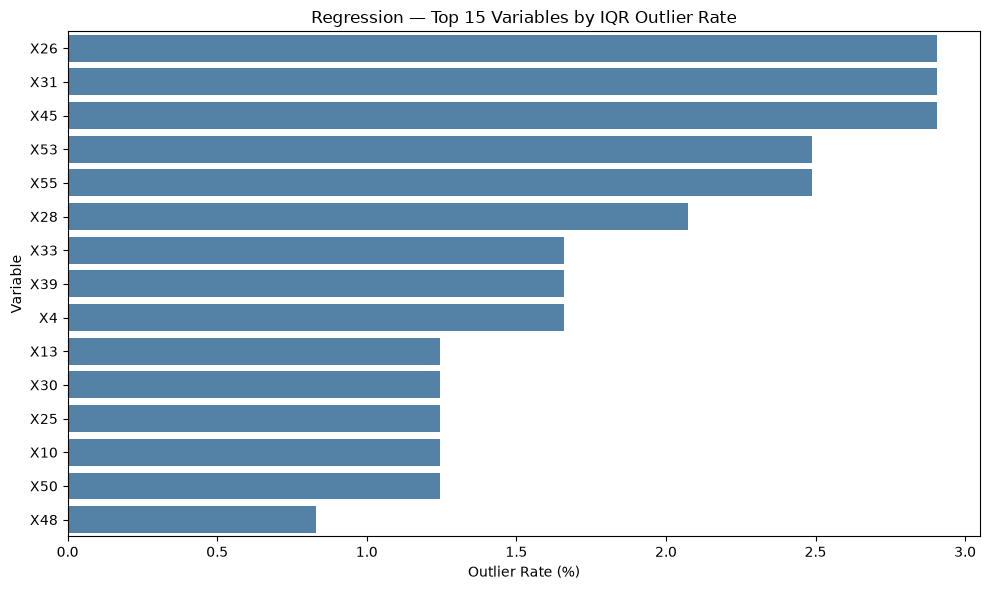

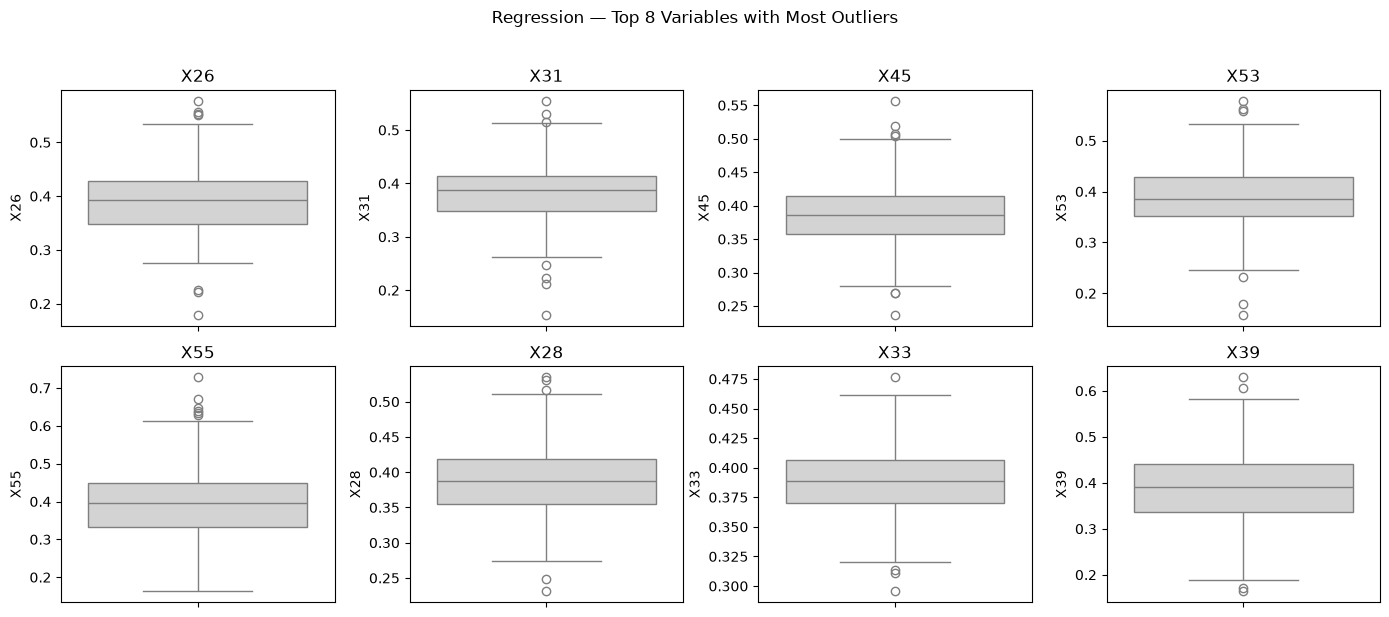

In [78]:
# 4) Regression 적용

# y(종속변수, 연속값)는 제외 → X 변수만 이상치 탐색
reg_outlier = outlier_summary(Regression, exclude_cols=["y"])

# 상위 15개 변수 확인 (표)
reg_outlier.head(15)

# 이상치 비율 순위 막대그래프
plot_outlier_rank(reg_outlier, title="Regression", top_n=15)

# 상위 8개 변수만 박스플롯으로 분포 확인
plot_top_boxplots(Regression, reg_outlier, top_n=8, title="Regression")

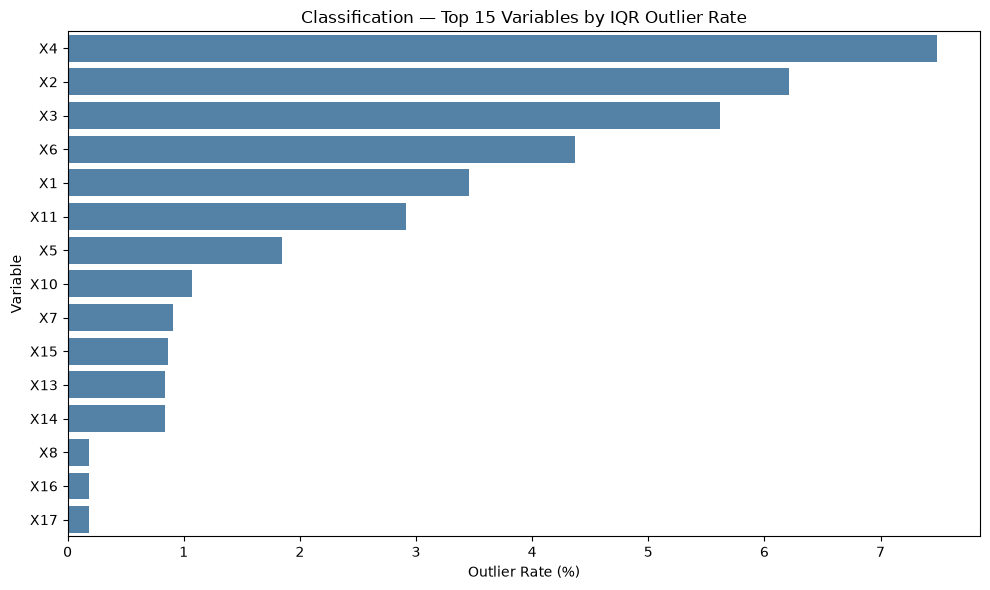

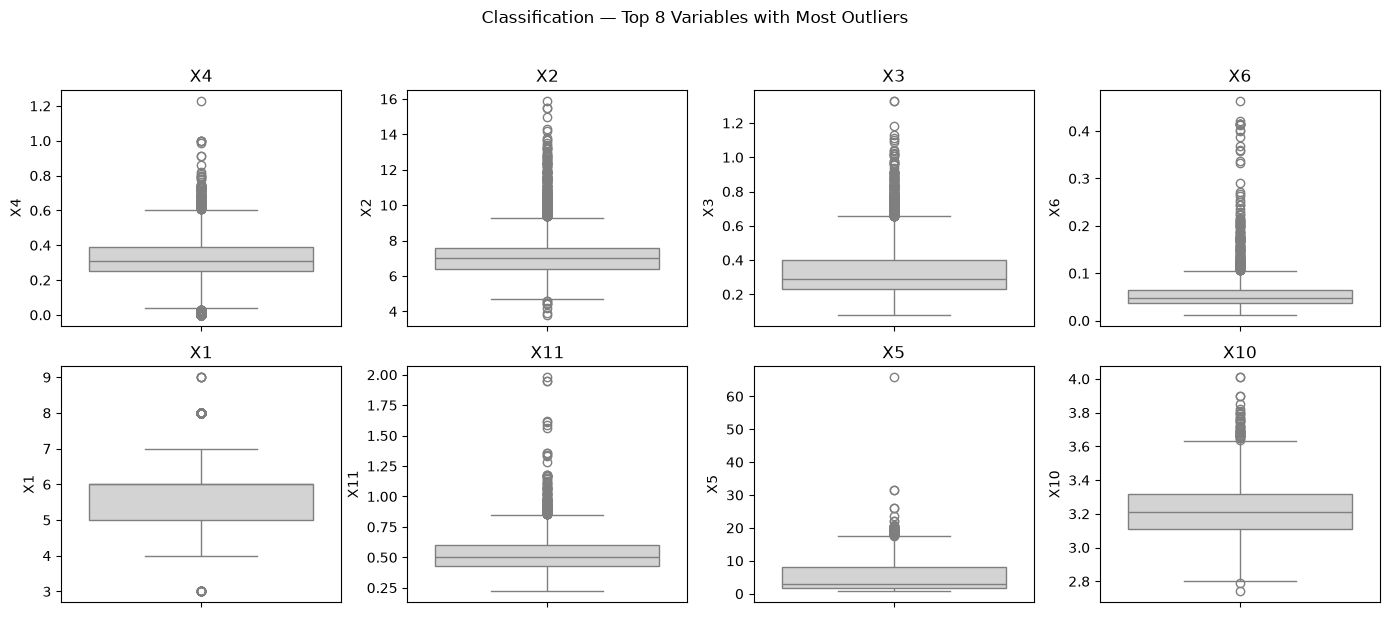

In [79]:
# 5) Classification 적용

# Y(종속변수, 범주)와 ID는 제외 → X 변수만 이상치 탐색
cla_outlier = outlier_summary(Classification, exclude_cols=["Y", "ID"])

# 상위 15개 변수 확인 (표)
cla_outlier.head(15)

plot_outlier_rank(cla_outlier, title="Classification", top_n=15)

plot_top_boxplots(Classification, cla_outlier, top_n=8, title="Classification")

**[과제 2]** 지수는 분류 데이터에서 target(Y)과 관련 있어 보이는 변수들을 추려내고 싶습니다. 그런데 변수가 많다 보니 하나씩 비교해보는 게 맞는 방법인지 확신이 서지 않습니다. 효율적으로 비교할 방법을 AI와 의논해서 정하고, 관련성이 높아 보이는 변수가 무엇인지 정리해 보세요.

In [80]:
# 1) Y와 X 연관성 요약 함수

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import f_classif, mutual_info_classif


def target_relation_summary(df, target_col="Y", exclude_cols=None):
    """
    분류 문제에서 각 X 변수가 Y(범주)와 얼마나 관련 있는지 점수화

    Parameters
    ----------
    df : DataFrame
        Classification 데이터
    target_col : str
        종속변수(범주) 컬럼명
    exclude_cols : list
        분석에서 제외할 컬럼 (ID 등)

    Returns
    -------
  DataFrame : 변수별 F-score, MI 점수 (높을수록 Y와 관련성이 큼)
    """
    exclude_cols = set(exclude_cols or [])
    exclude_cols.add(target_col)  # Y는 feature가 아니므로 제외

    # 숫자형 X만 추출
    num_cols = df.select_dtypes(include="number").columns
    feature_cols = [c for c in num_cols if c not in exclude_cols]

    X = df[feature_cols]
    y = df[target_col]

    # ── ANOVA F-test ─────────────────────────────────────
    # "클래스(Y)마다 X 평균이 다른가?" → 선형/평균 차이에 강함
    f_scores, p_values = f_classif(X, y)

    # ── Mutual Information ───────────────────────────────
    # "X를 알면 Y를 얼마나 잘 맞출 수 있는가?" → 비선형 관계도 일부 포착
    mi_scores = mutual_info_classif(X, y, random_state=42)

    summary = pd.DataFrame({
        "variable": feature_cols,
        "f_score": f_scores,
        "p_value": p_values,
        "mi_score": mi_scores,
    })

    # F-score 기준 내림차순 정렬 (mi_score로 정렬해도 됨)
    summary = summary.sort_values("f_score", ascending=False).reset_index(drop=True)
    return summary

In [81]:
# 2) 순위 막대그래프 함수

def plot_target_relation_rank(summary, score_col="f_score", title="Classification", top_n=15):
    """
    Y와 관련성이 높은 변수 top_n개를 막대그래프로 표시
    score_col: "f_score" 또는 "mi_score" 중 선택
    """
    top = summary.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top, y="variable", x=score_col, color="steelblue")

    if score_col == "f_score":
        plt.title(f"{title} — Top {top_n} Variables by ANOVA F-score")
        plt.xlabel("F-score (higher = stronger mean difference across classes)")
    else:
        plt.title(f"{title} — Top {top_n} Variables by Mutual Information")
        plt.xlabel("MI score (higher = more informative for Y)")

    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

In [82]:
# 3) 상위 변수만 boxplot 함수

def plot_target_relation_rank(summary, score_col="f_score", title="Classification", top_n=15):
    """
    Y와 관련성이 높은 변수 top_n개를 막대그래프로 표시
    score_col: "f_score" 또는 "mi_score" 중 선택
    """
    top = summary.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top, y="variable", x=score_col, color="steelblue")

    if score_col == "f_score":
        plt.title(f"{title} — Top {top_n} Variables by ANOVA F-score")
        plt.xlabel("F-score (higher = stronger mean difference across classes)")
    else:
        plt.title(f"{title} — Top {top_n} Variables by Mutual Information")
        plt.xlabel("MI score (higher = more informative for Y)")

    plt.ylabel("Variable")
    plt.tight_layout()
    plt.show()

In [83]:
# 4) 상위 변수만 violin plot 함수 (이게 더 좋다함)

def plot_top_violin_by_target(df, summary, target_col="Y", top_n=8, title="Classification"):
    """
    boxplot보다 분포 밀도까지 보고 싶을 때 사용
    """
    top_cols = summary.head(top_n)["variable"].tolist()

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))

    for ax, col in zip(axes.ravel(), top_cols):
        sns.violinplot(data=df, x=target_col, y=col, ax=ax, inner="box")
        ax.set_title(col)
        ax.set_xlabel("Y (class)")
        ax.set_ylabel(col)

    fig.suptitle(f"{title} — Top {top_n} Variables vs Target (Violin)", y=1.02)
    plt.tight_layout()
    plt.show()

In [87]:
def plot_top_by_target(df, summary, target_col="Y", top_n=8, title="Classification"):
    """
    1단계에서 상위로 나온 변수만 Y(클래스)별 boxplot으로 상세 확인
    """
    top_cols = summary.head(top_n)["variable"].tolist()

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))

    for ax, col in zip(axes.ravel(), top_cols):
        sns.boxplot(data=df, x=target_col, y=col, ax=ax)
        ax.set_title(col)
        ax.set_xlabel("Y (class)")
        ax.set_ylabel(col)

    fig.suptitle(f"{title} — Top {top_n} Variables vs Target", y=1.02)
    plt.tight_layout()
    plt.show()

def plot_top_violin_by_target(df, summary, target_col="Y", top_n=8, title="Classification"):
    """
    boxplot보다 분포 밀도까지 보고 싶을 때 사용
    """
    top_cols = summary.head(top_n)["variable"].tolist()

    fig, axes = plt.subplots(2, 4, figsize=(14, 6))

    for ax, col in zip(axes.ravel(), top_cols):
        sns.violinplot(data=df, x=target_col, y=col, ax=ax, inner="box")
        ax.set_title(col)
        ax.set_xlabel("Y (class)")
        ax.set_ylabel(col)

    fig.suptitle(f"{title} — Top {top_n} Variables vs Target (Violin)", y=1.02)
    plt.tight_layout()
    plt.show()

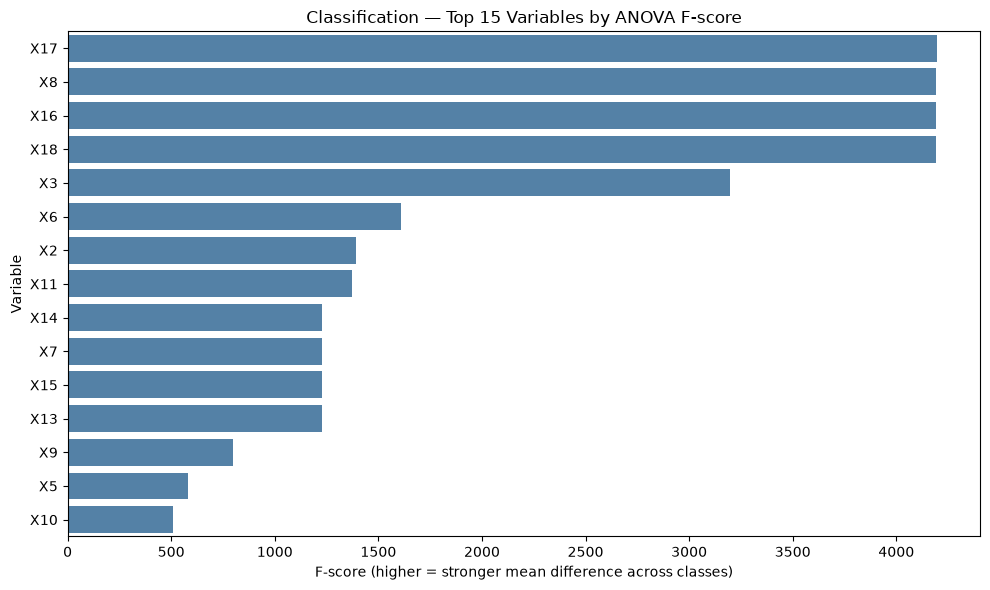

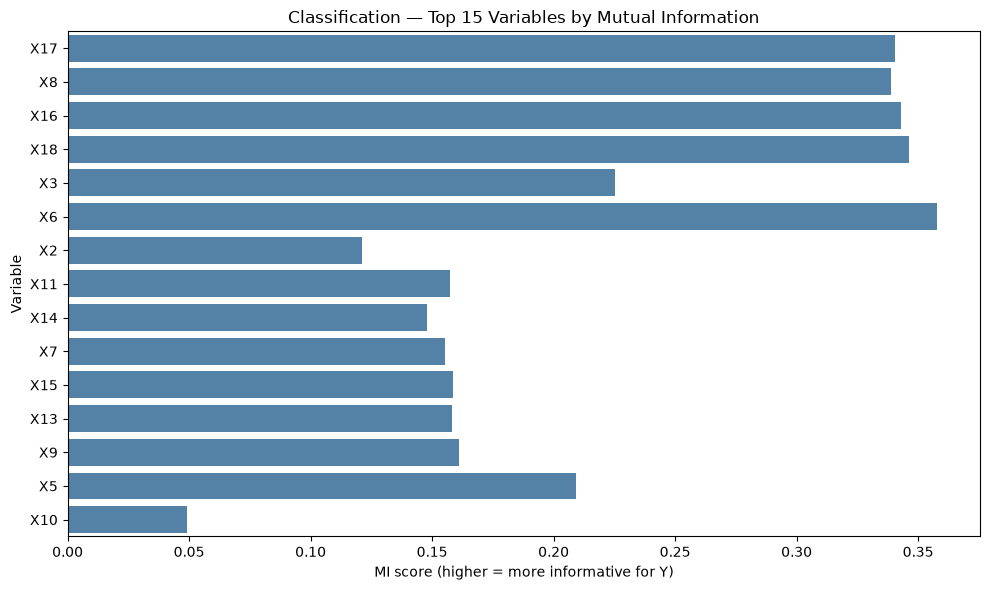

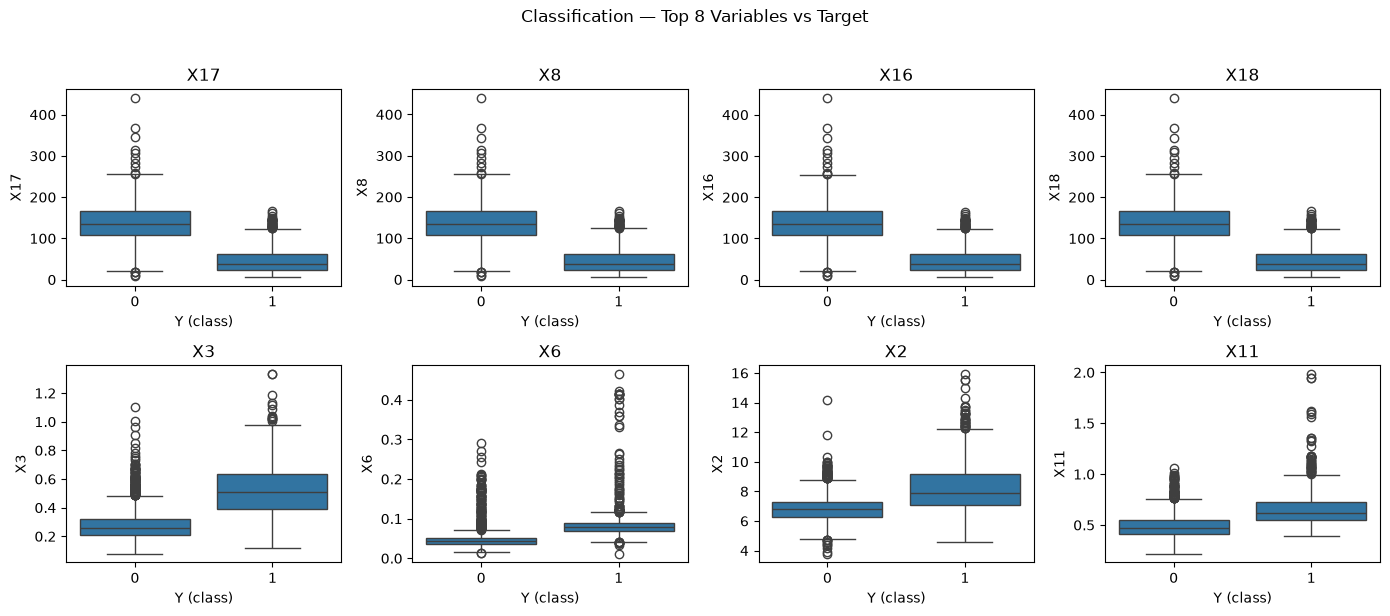

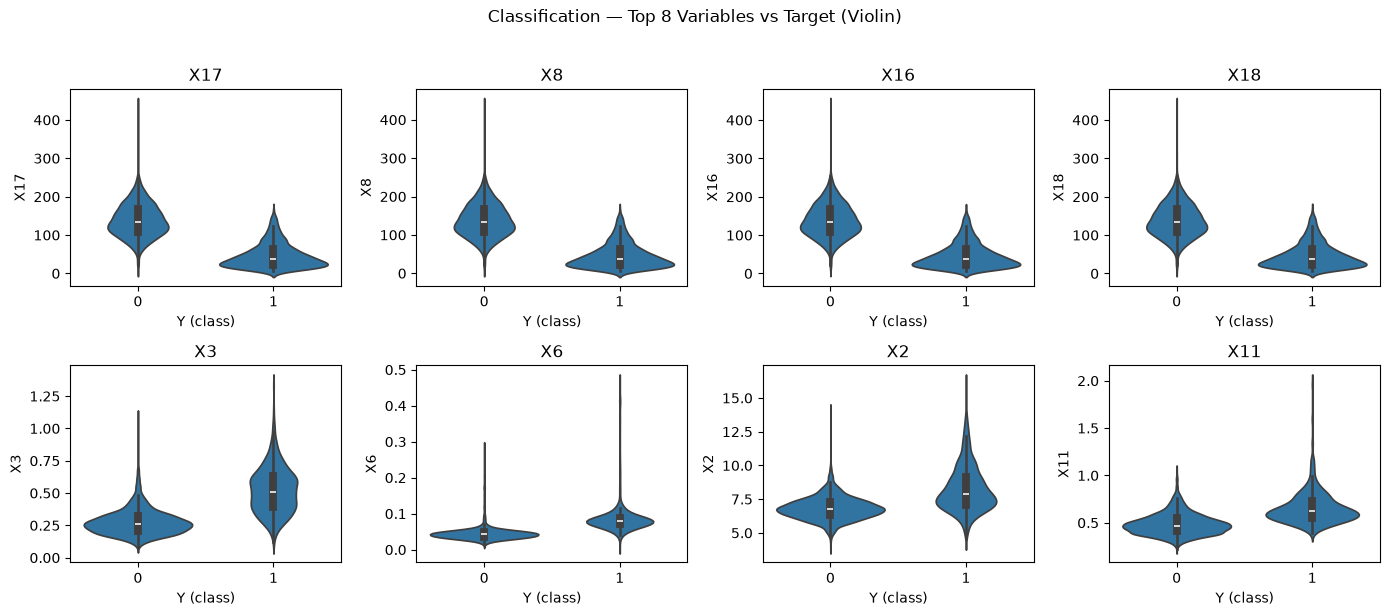

In [88]:
# 5) Classification 적용

# ID, Y 제외한 X 변수들의 Y 연관성 순위표
cla_relation = target_relation_summary(
    Classification,
    target_col="Y",
    exclude_cols=["ID"]
)

# 상위 15개 확인
cla_relation.head(15)

# F-score 기준 상위 변수 (평균 차이 관점)
plot_target_relation_rank(cla_relation, score_col="f_score", title="Classification", top_n=15)

# MI 기준 상위 변수 (비선형 관계까지 고려)
plot_target_relation_rank(cla_relation, score_col="mi_score", title="Classification", top_n=15)

# 상위 8개 변수 — 클래스별 boxplot으로 분포 차이 확인
plot_top_by_target(Classification, cla_relation, target_col="Y", top_n=8, title="Classification")

# (선택) violin plot으로 밀도까지 확인
plot_top_violin_by_target(Classification, cla_relation, target_col="Y", top_n=8, title="Classification")

In [89]:
# 6) 클래스별 평균 비교표

# 상위 8개 변수만 골라서 Y 클래스별 평균 비교
top8 = cla_relation.head(8)["variable"].tolist()
Classification.groupby("Y")[top8].mean()

,X17,X8,X16,X18,X3,X6,X2,X11
Y,,,,,,,,
0,138.645717,138.149985,138.649511,138.644028,0.278222,0.045772,6.836655,0.489149
1,46.883688,46.380374,46.873078,46.887190,0.523953,0.087221,8.292150,0.659262


### 읽으면서 체크할 포인트

- f_score가 높을수록 → Y 클래스마다 평균이 많이 다름
- mi_score가 높을수록 → X가 Y를 맞추는 데 유용
- p_value가 0.05 미만이면 → 통계적으로 유의한 차이 (참고용)
- 두 점수 모두 상위인 변수가 가장 유력한 후보
- ID는 반드시 제외

**[과제 3]** 지수는 모델에 같이 넣었을 때 문제가 될 만큼 상관관계가 높은 변수쌍이 있는지 궁금합니다. 히트맵을 눈으로 훑어보는 것만으로는 놓치는 게 있을 것 같아, 더 체계적으로 찾아낼 방법이 없을지 AI와 상의해 보세요.

> 행렬 전체를 보기보다, 숫자를 쌍으로 추출한 뒤 상위만 확인하기

### 추천 흐름 (3단계)
1단계: 상관계수 행렬 계산 (X만, Y·ID 제외) <br>
2단계: |r| 기준으로 변수쌍 표 추출 → 순위 정렬 <br>
3단계: 상위 쌍만 scatter / 클러스터 히트맵으로 확인 <br>

In [6]:
# 1단계 - 상관계수 행렬

# X(독립변수)만 대상, 종속변수·ID 제외
feature_cols = [c for c in Classification.select_dtypes(include="number").columns
                if c not in ["Y", "ID"]]

corr = Classification[feature_cols].corr()

In [7]:
# 2단계 - 높은 상관 변수쌍 자동 추출(핵심). 히트맵 대신 쌍목록을 만든다.

def find_high_corr_pairs(corr, threshold=0.8):
    """
    |상관계수| >= threshold 인 변수쌍만 추출
    - 대각선(자기 자신) 제외
    - (A,B)와 (B,A) 중복 제거
    - abs_corr 내림차순 정렬
    """
    pairs = []

    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):   # i < j 만 → 중복 방지
            r = corr.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append({
                    "var1": cols[i],
                    "var2": cols[j],
                    "corr": r,
                    "abs_corr": abs(r),
                })

    return pd.DataFrame(pairs).sort_values("abs_corr", ascending=False)

In [8]:
high_pairs = find_high_corr_pairs(corr, threshold=0.8)
high_pairs.head(20)

# 0.9 이상이면 거의 중복 변수. 하나를 제거하자.
# 0.8 이상이면 다중공선성 의심. 실무에서 자주 쓰는 기준임.
# 0.7 이상이면 주의 후보로 본다.

,var1,var2,corr,abs_corr
4,X8,X17,0.999987,0.999987
5,X8,X18,0.999987,0.999987
3,X8,X16,0.999987,0.999987
11,X17,X18,0.999974,0.999974
10,X16,X18,0.999974,0.999974
9,X16,X17,0.999974,0.999974
2,X7,X15,0.999874,0.999874
1,X7,X14,0.999868,0.999868
0,X7,X13,0.999868,0.999868
7,X13,X15,0.999744,0.999744


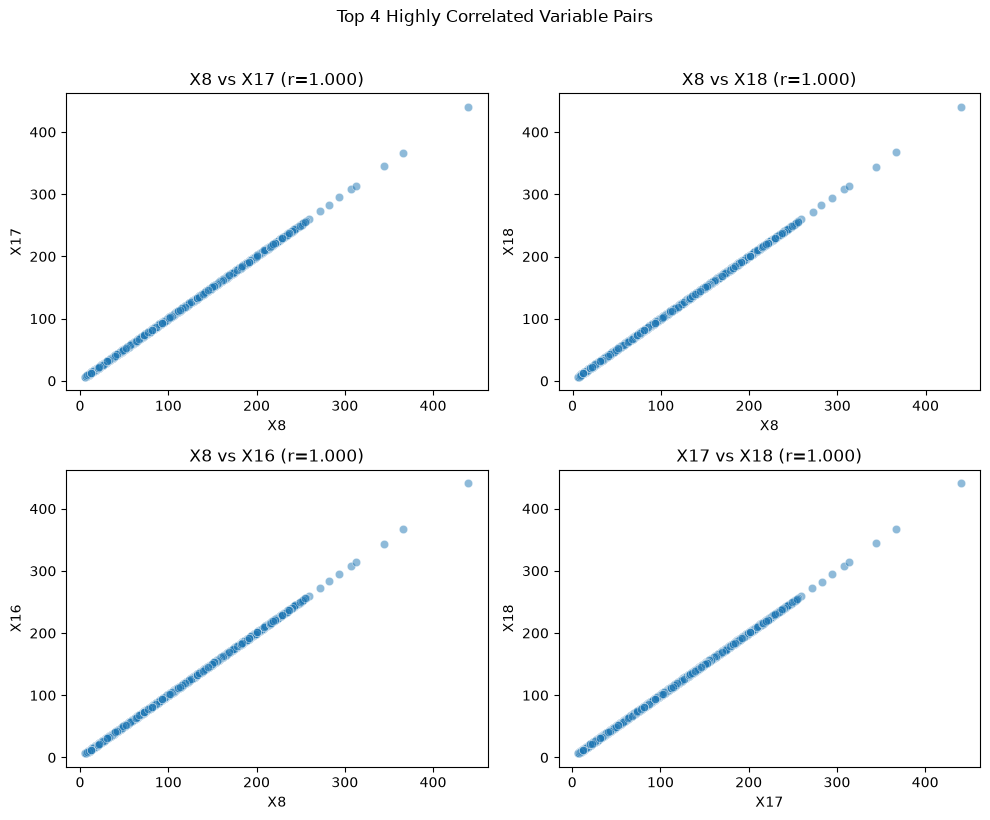

In [9]:
# 3단계 - 시각화는 상위만 한다.
## 1) 상위 쌍 scatter(2~5쌍)
# 상위 4쌍 scatter plot
top_n = 4
top_pairs = high_pairs.head(top_n)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()  # 2x2 → 1차원 배열로 펼치기

for ax, (_, row) in zip(axes, top_pairs.iterrows()):
    v1, v2 = row["var1"], row["var2"]
    r = row["corr"]

    sns.scatterplot(data=Classification, x=v1, y=v2, ax=ax, alpha=0.5)
    ax.set_title(f"{v1} vs {v2} (r={r:.3f})")
    ax.set_xlabel(v1)
    ax.set_ylabel(v2)

fig.suptitle("Top 4 Highly Correlated Variable Pairs", y=1.02)
plt.tight_layout()
plt.show()

In [97]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [10]:
import scipy
print(scipy.__version__)   # 버전이 나오면 OK

1.18.0


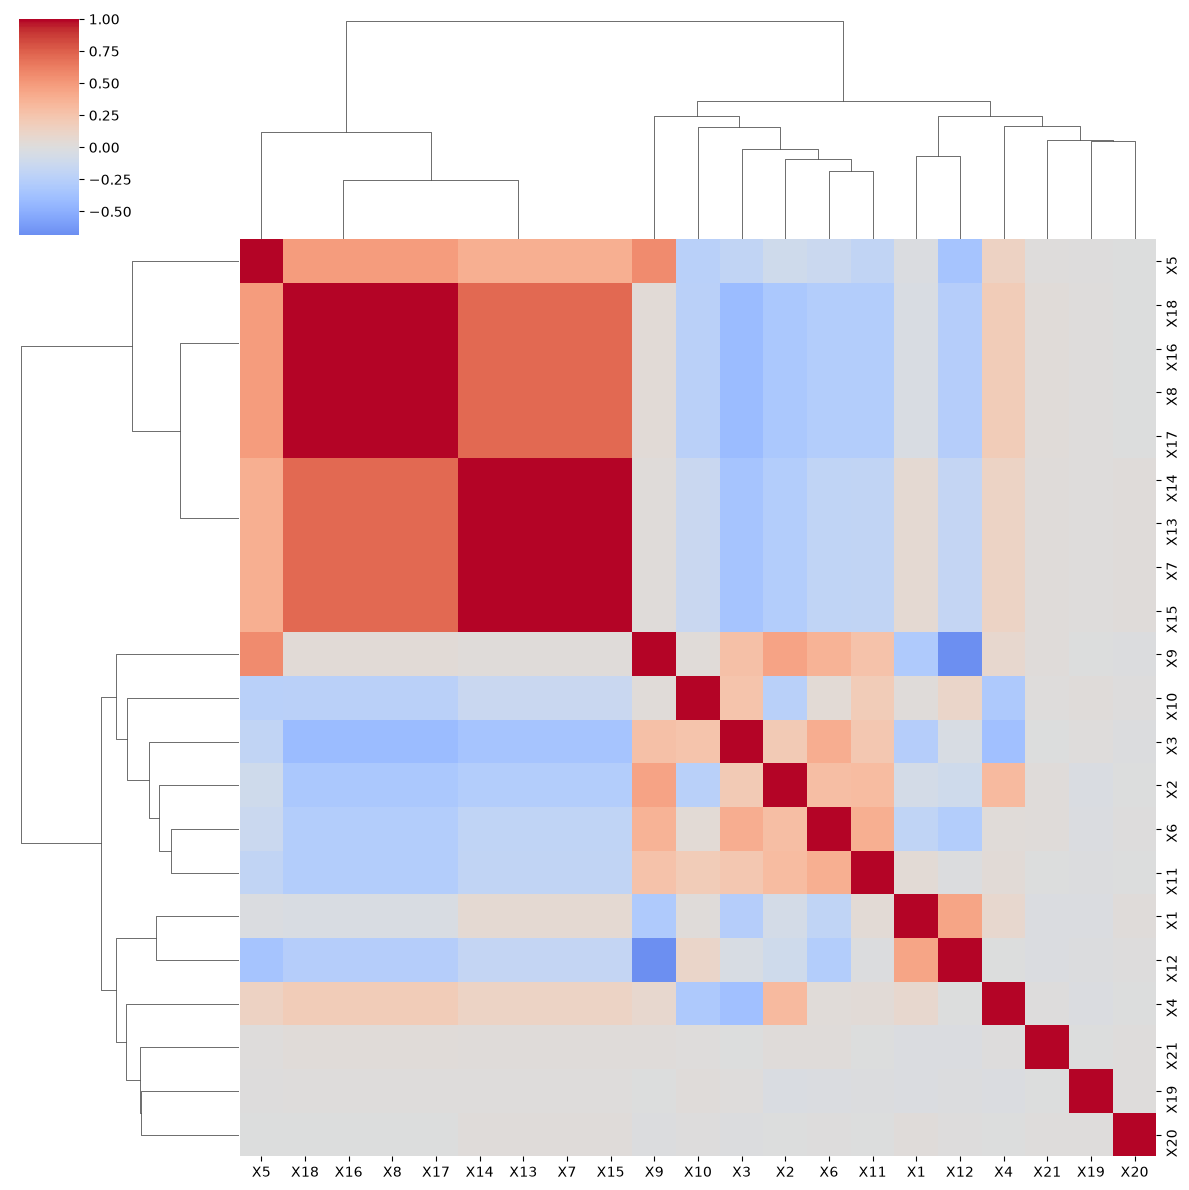

In [11]:
## 2) 클러스터 히트맵 (변수 그룹 파악)
# 비슷한 변수끼리 묶어서 보여줌 → 히트맵보다 구조 파악에 유리
sns.clustermap(corr, cmap="coolwarm", center=0, figsize=(12, 12))
plt.show()

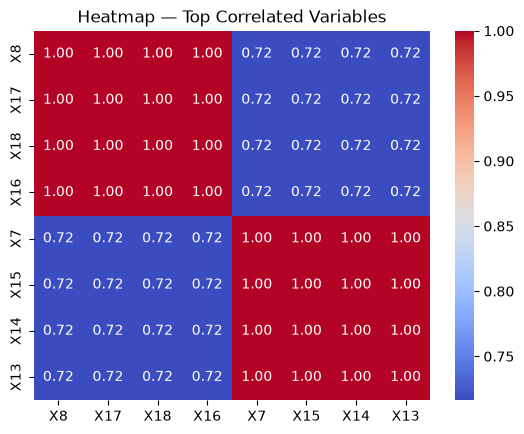

In [12]:
## 3) 상위 변수만 부분 히트맵
# 상위 쌍에 등장한 변수만 골라 작은 히트맵
top_vars = pd.unique(high_pairs.head(10)[["var1", "var2"]].values.ravel())
sns.heatmap(corr.loc[top_vars, top_vars], annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Heatmap — Top Correlated Variables")
plt.show()

In [ ]:
%pip install statsmodels

In [14]:
## 4단계 - VIF:모델 관점 점검. 같이 넣었을때 문제가 되나를 선형모델 기준으로 보려면 VIF가 유용. VIF>5 이면 주의, VIF>10이면 다중공선성 문제 가능성 큼
# VIF:한 변수가 나머지 전부와 겹치는 정도
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(df, feature_cols):
    X = df[feature_cols].dropna()
    rows = []
    for i, col in enumerate(feature_cols):
        rows.append({
            "variable": col,
            "VIF": variance_inflation_factor(X.values, i),
        })
    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

### 5-2) 전처리 심화

**[과제 4]** 지수는 수치형 변수들의 스케일이 제각각이라 모델 학습 전에 스케일링이 필요하다고 판단했습니다. 그런데 Min-Max와 Standard 중 어떤 걸 써야 할지, 변수마다 다르게 적용해야 하는 건 아닌지 확신이 서지 않습니다. AI와 어떤 스케일링이 적합할지 논의하고, 정한 방식을 적용해 보세요.

**[과제 5]** 지수는 앞서(5-1) 상관관계가 높은 변수쌍 후보를 찾아뒀습니다. 그런데 막상 "상관계수가 몇 이상이면 지워야 하는지", "쌍 중에서 어떤 변수를 남겨야 하는지"는 정해진 답이 없어 고민이 됩니다. threshold를 어떻게 잡을지, 어떤 변수를 남길지 AI와 함께 근거를 세워서 정하고, 정한 기준대로 제거한 뒤 모델 성능이 어떻게 달라지는지 확인해 보세요.

### 5-3) 모델링 심화

**[과제 6]** 지수는 지금까지 학습시킨 회귀 모델과 분류 모델이 각각 어떤 변수를 근거로 예측하는지 궁금합니다. 회귀와 분류 각각에서 성능이 가장 좋았던 모델을 골라, 변수 중요도를 구하고 시각화하는 방법을 AI와 함께 알아보고 두 결과를 비교해 보세요.

### 5-4) 모델링 고도화 심화

**[과제 7]** 지수는 모델 성능을 더 끌어올리고 싶은데, 직접 k-fold cross validation으로 하나하나 비교해봐야 할지, GridSearchCV로 자동 탐색해야 할지, 아니면 RandomizedSearchCV가 더 나을지 헷갈립니다. 각 방법이 어떤 상황에 적합한지 AI와 상의해서 이번 데이터와 모델에 맞는 방법을 정하고, 정한 방법으로 직접 탐색해 보세요.

**[과제 8]** 지수는 과제 7에서 탐색 방법은 정했지만, 막상 하이퍼파라미터 값을 어느 범위까지 탐색해야 할지 감이 잡히지 않습니다. 너무 좁게 잡으면 의미가 없고, 너무 넓게 잡으면 시간이 오래 걸릴 것 같아 고민입니다. 모델 특성과 데이터 크기를 고려했을 때 적절한 범위가 어느 정도일지 AI와 상의해서 정하고 그 범위로 실제 탐색을 수행해 보세요.